In [ ]:
import pandas as pd
import os
import glob
from datetime import datetime

# 1. LOAD FILE LIST
# If you saved the CSV from the previous step:
# df = pd.read_csv("mea_file_locations.csv")

# OR, if you want to run it fresh right now:
root_search_path = "MEA_Analysis/AnalyzedData/CDKL5_T1"
#ANCHOR = root_search_path.split(os.sep)[-3]  # anything before project name
ANCHOR = "AnalyzedData"  # this is the folder that anchors the structure we want to parse
files = glob.glob(os.path.join(root_search_path, "**", "*network*.json"), recursive=True)
df = pd.DataFrame(files, columns=['full_path'])


def parse_path_metadata(path):
    """
    Extracts metadata from the standard path structure:
    .../AnalyzedData/Genotype/Date/ChipID/Network/RunID/WellID/...
    """
    try:
        parts = path.split(os.sep)
        
        # We anchor everything relative to "AnalyzedData" to be safe
        if ANCHOR in parts:
            idx = parts.index(ANCHOR)

            # Extract based on your specific directory depth
            project = parts[idx + 1]  # e.g., CDKL5_T1
            date_str = parts[idx + 2]  # e.g., 240531
            chip_id  = parts[idx + 3]  # e.g., M07420
            # parts[idx + 4] is usually "Network"
            run_id   = parts[idx + 5]  # e.g., 000052
            well_id  = parts[idx + 6]  # e.g., well005
            
            return pd.Series([project, date_str, chip_id, run_id, well_id])
        else:
            return pd.Series([None, None, None, None, None])
            
    except IndexError:
        return pd.Series([None, None, None, None, None])

# 2. APPLY EXTRACTION
print(" dissecting path names...")
metadata_cols = ["Project", "Date", "Chip_ID", "RunID", "Well"]
df[metadata_cols] = df['full_path'].apply(parse_path_metadata)
#puth full_path to last column
df = df[[col for col in df.columns if col != 'full_path'] + ['full_path']]


# 4. REVIEW
print(f"Successfully dissected {len(df)} paths.")
print("\nSnapshot of extracted metadata:")
print(df.head())

# 5. SAVE
#df.to_csv("/pscratch/sd/m/mpatil1/MEA_Analysis/IPNAnalysis/workbooks/mea_metadata_index_networks.csv", index=False)

# SEE the network json structure first to do the downstream analysis

In [ ]:
import json
import pandas as pd

# 1. Select the first file from our dissected dataframe
# We use .iloc[0] to grab the first row
sample_path = df.iloc[0]['full_path']
#print(f"Inspecting file: {sample_path}\n")
#sample_path = '/pscratch/sd/m/mpatil1/MEA_Analysis/AnalyzedData/CDKL5_T1/240531/M07420/Network/000052/well004/network_results.json'
# 2. Load the JSON data
with open(sample_path, 'r') as f:
    data = json.load(f)

# 3. Helper function to print the structure without flooding the screen
# This will show you the Keys and the Type of data inside (e.g., float, list of 6000 items)
def print_structure(d, indent=0):
    spacing = "  " * indent
    if isinstance(d, dict):
        for key, value in d.items():
            if isinstance(value, dict):
                print(f"{spacing}- {key}: (Nested Dictionary)")
                print_structure(value, indent + 1)
            elif isinstance(value, list):
                print(f"{spacing}- {key}: List [{len(value)} items]")
            else:
                print(f"{spacing}- {key}: {type(value).__name__} (e.g., {value})")
    else:
        print(f"{spacing} (Not a dictionary)")

# 4. Print the "Map" of your JSON
print("--- JSON FILE STRUCTURE ---")
print_structure(data)

# 5. Check for specific "Gold Mine" keys
# These are the standard keys usually found in MaxWell/MACS outputs.
# We try to print them specifically to see if they exist.
print("\n--- CHECKING FOR COMMON METRICS ---")
possible_keys = ['mean_firing_rate', 'mean_burst_rate', 'network_burst_frequency', 'burst_duration_mean']

found_metrics = {}
for key in possible_keys:
    # Check top level
    if key in data:
        found_metrics[key] = data[key]
    # Sometimes metrics are hidden inside a 'summary' or 'network' sub-dictionary
    elif 'summary' in data and key in data['summary']:
        found_metrics[key] = data['summary'][key]

print(f"Found specific metrics: {json.dumps(found_metrics, indent=2)}")

In [ ]:
import tqdm
import numpy as np
def extract_metrics(row):
    path = row['full_path']

    metrics = {}

    try:
        with open(path, "r") as f:
            data = json.load(f)

        # -----------------------------
        # Helper
        # -----------------------------
        def extract_block(block, prefix):
            if block is None:
                return

            m = block.get("metrics", {})
            events = block.get("events", [])

            # -------- Scalars --------
            metrics[f"{prefix}_count"] = m.get("count", np.nan)
            metrics[f"{prefix}_rate_hz"] = m.get("rate", np.nan)

            metrics[f"{prefix}_duration_mean"] = m.get("duration", {}).get("mean")
            metrics[f"{prefix}_duration_std"]  = m.get("duration", {}).get("std")
            metrics[f"{prefix}_duration_cv"]   = m.get("duration", {}).get("cv")

            metrics[f"{prefix}_ibi_mean"] = m.get("inter_event_interval", {}).get("mean")
            metrics[f"{prefix}_ibi_std"]  = m.get("inter_event_interval", {}).get("std")
            metrics[f"{prefix}_ibi_cv"]   = m.get("inter_event_interval", {}).get("cv")

            metrics[f"{prefix}_intensity_mean"] = m.get("intensity", {}).get("mean")

            metrics[f"{prefix}_spikes_mean"] = m.get("spikes_per_burst", {}).get("mean")
            metrics[f"{prefix}_participation_mean"] = m.get("participation", {}).get("mean")
            metrics[f"{prefix}_burst_peak_mean"] = m.get("burst_peak", {}).get("mean")
            metrics[f"{prefix}_peak_sync_mean"] = m.get("peak_synchrony", {}).get("mean")

            # -------- Distributions --------
            durations = []
            peaks = []
            intensities = []
            sync_energy = []
            fragments = []

            for ev in events:
                durations.append(ev.get("duration_s", np.nan))
                peaks.append(ev.get("peak_synchrony", np.nan))
                intensities.append(ev.get("total_spikes", np.nan))
                sync_energy.append(ev.get("synchrony_energy", np.nan))

                if "fragment_count" in ev:
                    fragments.append(ev["fragment_count"])

            metrics[f"{prefix}_durations"] = durations
            metrics[f"{prefix}_peaks"] = peaks
            metrics[f"{prefix}_intensity"] = intensities
            metrics[f"{prefix}_sync_energy"] = sync_energy

            if prefix == "nb":
                metrics[f"{prefix}_fragment_list"] = fragments
                metrics[f"{prefix}_fragment_mean"] = np.mean(fragments) if fragments else np.nan

        # -----------------------------
        # Apply
        # -----------------------------
        extract_block(data.get("burstlets"), "bl")
        extract_block(data.get("network_bursts"), "nb")
        extract_block(data.get("superbursts"), "sb")

        # -----------------------------
        # Diagnostics (DO NOT IGNORE THIS)
        # -----------------------------
        diag = data.get("diagnostics", {})
        for k, v in diag.items():
            metrics[f"diag_{k}"] = v

        metrics["n_units"] = data.get("n_units", np.nan)

    except Exception as e:
        print(f"[ERROR] {path}: {e}")

    return pd.Series(metrics)

# --- 3. RUN EXTRACTION ---
print("Starting unified extraction (Scalars + Lists)...")

# If you have tqdm installed, use progress_apply, otherwise use apply
if hasattr(tqdm, 'pandas'):
    df_metrics = df.progress_apply(extract_metrics, axis=1)
else:
    df_metrics = df.apply(extract_metrics, axis=1)

# Concatenate metadata with results
result_df = pd.concat([df, df_metrics], axis=1)



In [ ]:
import pandas as pd

ref_df = pd.read_excel("/pscratch/sd/m/mpatil1/Data/CDKL5_T1/CDKL5_T1_C1_reff_new.xlsx")
print(ref_df.columns)

# --- 2. TRANSFORMATION LOGIC ---

# Step A: Split the strings into actual Python lists
ref_df['Wells_List'] = ref_df['Wells_Recorded'].astype(str).str.split(',')
ref_df['Source_List'] = ref_df['Neuron Source'].astype(str).str.split(',')

# Step B: Explode the lists into rows (keeps alignment)
exploded_df = ref_df.explode(['Wells_List', 'Source_List'])

# Step C: Cleanup
exploded_df['Well'] = exploded_df['Wells_List'].str.strip()
exploded_df['NeuronType'] = exploded_df['Source_List'].str.strip()

# Step D: FIX — convert 1-based wells to 0-based and format
exploded_df['Well'] = (
    'well'
    + (exploded_df['Well'].astype(int) - 1)
      .astype(str)
      .str.zfill(3)
)

# Filter to keep only the clean columns
clean_ref_df = exploded_df[['Date', 'ID', 'Run #', 'Well', 'NeuronType', 'Assay', 'DIV']]

# --- 3. VIEW RESULTS ---
print("Transformation complete.")
print(f"Original rows: {len(ref_df)}")
print(f"Exploded rows: {len(clean_ref_df)}")
print("\nFirst 10 rows of clean metadata:")
print(clean_ref_df.head(10))

# Save if needed
# clean_ref_df.to_csv("clean_metadata_map.csv", index=False)

In [ ]:
result_df.rename(columns={"RunID": "Run #","Chip_ID": "ID"}, inplace=True)

In [ ]:
result_df['Date'] = result_df['Date'].astype(str)

In [ ]:
result_df['Run #'] = result_df['Run #'].astype(str).str.zfill(6)
clean_ref_df['Run #'] = clean_ref_df['Run #'].astype(str).str.zfill(6)
print(result_df['Well'].unique()[:10])
print(clean_ref_df['Well'].unique()[:10])

In [ ]:
# JSON-derived table must be unique
assert not result_df.duplicated(
    ['ID','Date','Run #','Well']
).any(), "Duplicate JSON-derived rows detected"

# Metadata table must be unique
assert not clean_ref_df.duplicated(
    ['ID','Date','Run #','Well']
).any(), "Duplicate metadata rows detected"

In [ ]:
merged_df = pd.merge(
    result_df,
    clean_ref_df,
    how='left',
    on=['ID', 'Run #', 'Well'],
    validate='one_to_one'
)

In [ ]:
#order by run #
merged_df.sort_values(by=['ID', 'Run #', 'Well'], inplace=True)

In [ ]:
merged_df.head()

In [1]:
#save final merged table
merged_df.to_csv("/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Analysis_extract_waveform/AnalyzedData/PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS/summary_old.csv", index=False)

NameError: name 'merged_df' is not defined

In [ ]:
#split merged_df into two dataframes based on Assay type
network_assay_df = merged_df[merged_df['Assay'] == 'Network Today']
neuronal_assay_df = merged_df[merged_df['Assay'] == 'Neuronal Units 9']
#neuronal_assay_df = merged_df[merged_df['Assay'] == 'Neuronal unit']

In [ ]:
network_assay_df.head()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
network_assay_df = pd.read_csv("/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Analysis_extract_waveform/AnalyzedData/PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS/summary_old.csv")

In [5]:
network_assay_df.head()

,json_path,project,date,chip_id,run_id,well,NeuronType,burstlets_metrics_count,burstlets_metrics_rate,burstlets_metrics_duration_mean,...,Unnamed: 987,Unnamed: 988,Unnamed: 989,Unnamed: 990,Unnamed: 991,Unnamed: 992,Unnamed: 993,Unnamed: 994,Unnamed: 995,A1
0,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well000,HET,111.0,0.369951,6.661351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well001,HET,97.0,0.323291,0.126598,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well002,HET,31.0,0.103320,0.073226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well003,WT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well004,WT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
subset = network_assay_df[network_assay_df['NeuronType'].notna()]

In [7]:
subset.head()

,json_path,project,date,chip_id,run_id,well,NeuronType,burstlets_metrics_count,burstlets_metrics_rate,burstlets_metrics_duration_mean,...,Unnamed: 987,Unnamed: 988,Unnamed: 989,Unnamed: 990,Unnamed: 991,Unnamed: 992,Unnamed: 993,Unnamed: 994,Unnamed: 995,A1
0,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well000,HET,111.0,0.369951,6.661351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well001,HET,97.0,0.323291,0.126598,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well002,HET,31.0,0.103320,0.073226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well003,WT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,/mnt/Vol20tb1/user_workspaces/mmpatil/MEA-Anal...,PYTHON_V1/KCNT1_M1Plus_T1_01142026_PVS,260217,M07301,112,well004,WT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
subset.fillna(0, inplace=True)

/tmp/ipykernel_3276283/1902452600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset.fillna(0, inplace=True)


In [9]:
subset['NeuronType'].unique()

array(['HET', 'WT', 'HET_VU30uM', 'HET_Q300uM', 'WT_VU30uM', 'HET_DMSO',
       'WT_DMSO', 'WT_Q300uM', 'WT_Vu15uM', 'HET_Q100uM', 'HET_Vu5uM',
       'HET_Vu15uM'], dtype=object)

Using column: burstlets_metrics_count
            count        mean  median        std        sem
NeuronType                                                 
HET            14   86.357143    80.0  55.269420  14.771374
WT              8   96.625000    88.5  57.710948  20.403902
HET_VU30uM      1   19.000000    19.0        NaN        NaN
HET_Q300uM      0         NaN     NaN        NaN        NaN
WT_VU30uM       1   73.000000    73.0        NaN        NaN
HET_DMSO        4  144.000000   135.0  51.029403  25.514702
WT_DMSO         3   71.000000    75.0  10.583005   6.110101
WT_Q300uM       0         NaN     NaN        NaN        NaN
WT_Vu15uM       2   27.000000    27.0  36.769553  26.000000
HET_Q100uM      1    1.000000     1.0        NaN        NaN
HET_5uM         0         NaN     NaN        NaN        NaN
HET_Vu15uM      2   29.000000    29.0  38.183766  27.000000

Kruskal-Wallis H = 13.6085, p = 0.09256

Pairwise Welch t-tests:
HET          vs WT           -> t = -0.4076, p = 0.6896


/tmp/ipykernel_3276283/4279114827.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compare_df.groupby('NeuronType')[metric_col]


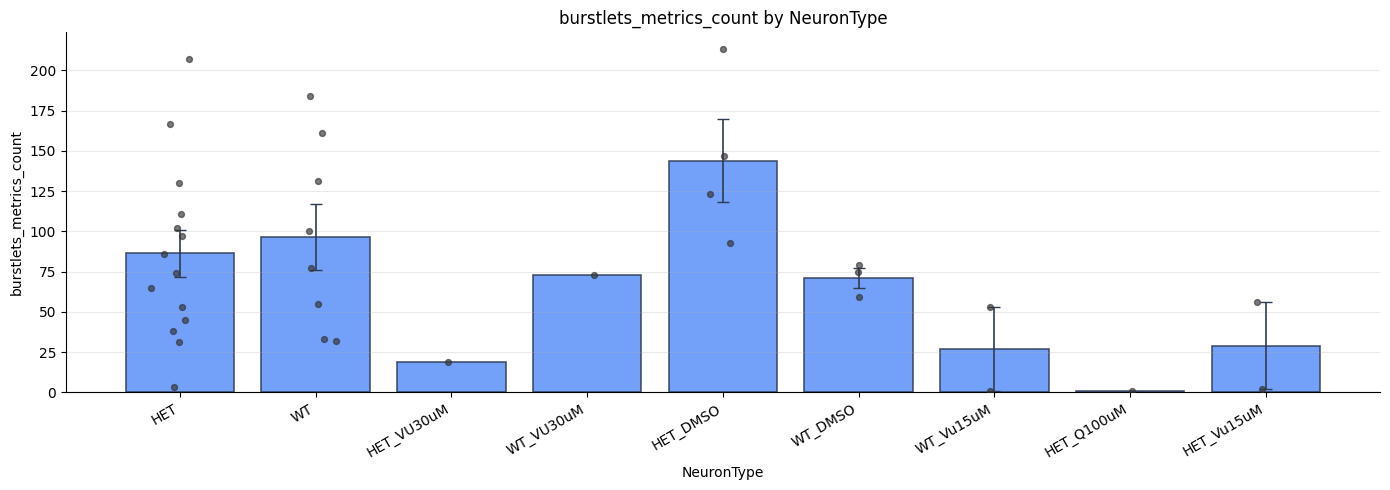

In [10]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal, ttest_ind

# Compare NeuronType groups for the requested burst-rate column.
metric_candidates = ['burstlets_metrics_count']
metric_col = next((c for c in metric_candidates if c in network_assay_df.columns), None)

if metric_col is None:
    raise KeyError(f'None of these columns were found: {metric_candidates}')

compare_order = [
    'HET', 'WT', 'HET_VU30uM', 'HET_Q300uM', 'WT_VU30uM', 'HET_DMSO',
    'WT_DMSO', 'WT_Q300uM', 'WT_Vu15uM', 'HET_Q100uM', 'HET_5uM',
    'HET_Vu15uM'
]

compare_df = network_assay_df.loc[
    network_assay_df['NeuronType'].isin(compare_order),
    ['NeuronType', metric_col]
].copy()
compare_df[metric_col] = pd.to_numeric(compare_df[metric_col], errors='coerce')
compare_df = compare_df.dropna(subset=[metric_col])
compare_df['NeuronType'] = pd.Categorical(compare_df['NeuronType'], categories=compare_order, ordered=True)

summary = (
    compare_df.groupby('NeuronType')[metric_col]
    .agg(['count', 'mean', 'median', 'std'])
    .reindex(compare_order)
)
summary['sem'] = summary['std'] / np.sqrt(summary['count'])

print(f'Using column: {metric_col}')
print(summary)

# Overall non-parametric test across all available groups
values = [compare_df.loc[compare_df['NeuronType'] == g, metric_col].to_numpy() for g in compare_order]
values = [v for v in values if len(v) > 0]
if len(values) >= 2:
    stat, p = kruskal(*values)
    print(f'\nKruskal-Wallis H = {stat:.4f}, p = {p:.4g}')

# Pairwise Welch t-tests
print('\nPairwise Welch t-tests:')
for g1, g2 in itertools.combinations(compare_order, 2):
    x = compare_df.loc[compare_df['NeuronType'] == g1, metric_col].to_numpy()
    y = compare_df.loc[compare_df['NeuronType'] == g2, metric_col].to_numpy()
    if len(x) < 2 or len(y) < 2:
        continue
    stat, p = ttest_ind(x, y, equal_var=False, nan_policy='omit')
    print(f'{g1:12s} vs {g2:12s} -> t = {stat:.4f}, p = {p:.4g}')

# Bar plot with mean ± SEM
plot_order = [g for g in compare_order if g in compare_df['NeuronType'].unique()]
plot_summary = summary.loc[plot_order].copy()
plot_summary = plot_summary.dropna(subset=['mean'])

fig, ax = plt.subplots(figsize=(14, 5))
bar_color = '#5B8FF9'
edge_color = '#2F3B52'

xpos = np.arange(len(plot_summary))
ax.bar(
    xpos,
    plot_summary['mean'].to_numpy(),
    yerr=plot_summary['sem'].to_numpy(),
    capsize=4,
    color=bar_color,
    edgecolor=edge_color,
    alpha=0.85,
    linewidth=1.2,
    error_kw={'elinewidth': 1.2, 'ecolor': edge_color},
)

# Optional: overlay individual points
for i, g in enumerate(plot_summary.index):
    y = compare_df.loc[compare_df['NeuronType'] == g, metric_col].to_numpy()
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=18, alpha=0.65, color='#333333', zorder=3)

ax.set_xticks(xpos)
ax.set_xticklabels(plot_summary.index, rotation=30, ha='right')
ax.set_title(f'{metric_col} by NeuronType')
ax.set_xlabel('NeuronType')
ax.set_ylabel(metric_col)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


USING METRIC: burstlets_metrics_count

            count        mean      median        std        sem
NeuronType                                                     
WT            6.0   97.833333   93.000000  45.574847  18.605853
WT_DMSO       3.0   71.000000   75.000000  10.583005   6.110101
WT_Vu15uM     2.0   27.000000   27.000000  36.769553  26.000000
WT_VU30uM     1.0   73.000000   73.000000        NaN        NaN
WT_Q300uM     NaN         NaN         NaN        NaN        NaN
HET           7.0   96.214286   79.666667  56.933905  21.518994
HET_DMSO      4.0  144.000000  135.000000  51.029403  25.514702
HET_5uM       NaN         NaN         NaN        NaN        NaN
HET_Q100uM    1.0    1.000000    1.000000        NaN        NaN
HET_Vu15uM    2.0   29.000000   29.000000  38.183766  27.000000
HET_VU30uM    1.0   19.000000   19.000000        NaN        NaN
HET_Q300uM    NaN         NaN         NaN        NaN        NaN
Skipping WT vs WT_VU30uM (not enough samples)
Skipping WT vs WT_

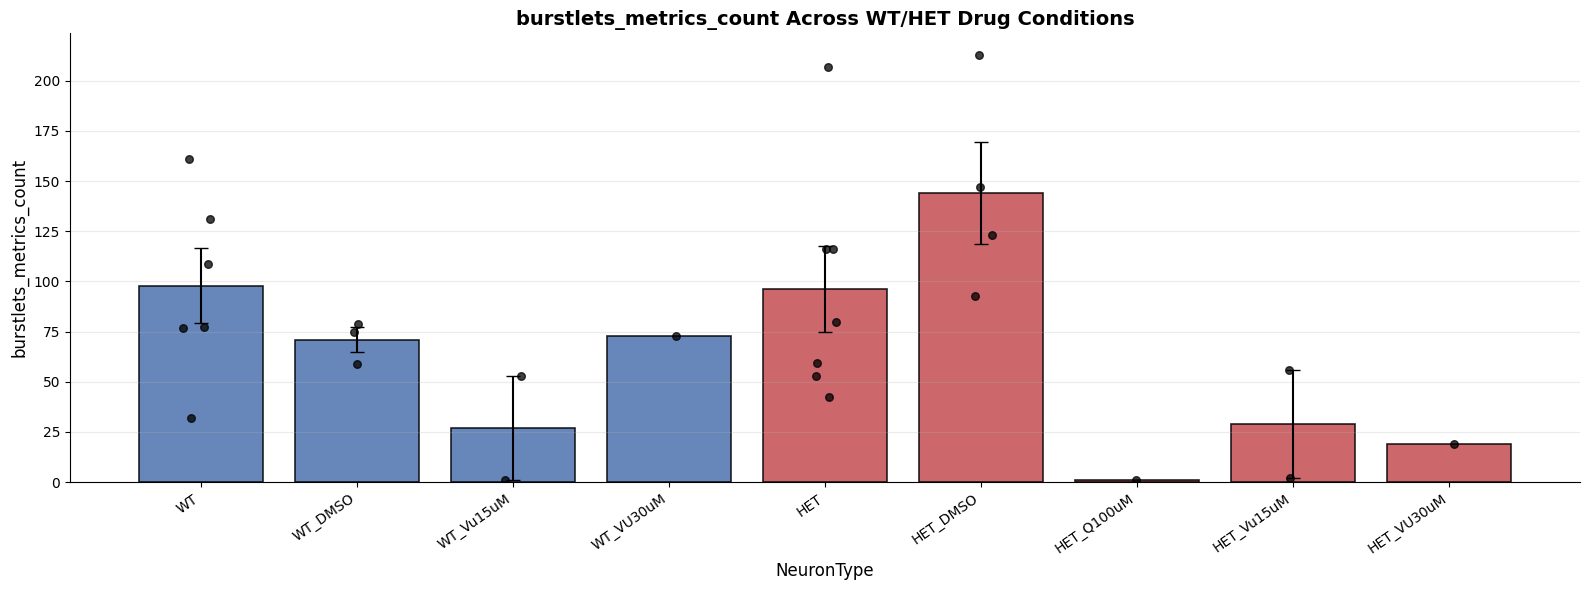

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# =========================================================
# SETTINGS
# =========================================================

metric_candidates = ['burstlets_metrics_count']

metric_col = next(
    (c for c in metric_candidates if c in network_assay_df.columns),
    None
)

if metric_col is None:
    raise KeyError(f'None of these columns were found: {metric_candidates}')

# ---------------------------------------------------------
# Planned biologically meaningful comparisons
# ---------------------------------------------------------

planned_comparisons = [

    # Disease phenotype
    ('WT', 'HET'),

    # WT vehicle/drug effects
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_Q300uM'),

    # HET vehicle/drug effects
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_Q300uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_5uM'),

    # Rescue comparisons
    ('WT', 'HET_VU30uM'),
    ('WT', 'HET_Vu15uM'),
    ('WT', 'HET_Q300uM'),
    ('WT', 'HET_Q100uM'),
    ('WT', 'HET_Vu5uM'),
]

# ---------------------------------------------------------
# Plot order
# ---------------------------------------------------------

plot_order = [
    'WT',
    'WT_DMSO',
    'WT_Vu15uM',
    'WT_VU30uM',
    'WT_Q300uM',

    'HET',
    'HET_DMSO',
    'HET_5uM',
    'HET_Q100uM',
    'HET_Vu15uM',
    'HET_VU30uM',
    'HET_Q300uM',
]

# =========================================================
# DATA CLEANING
# =========================================================

compare_df = network_assay_df.copy()

compare_df = compare_df.loc[
    compare_df['NeuronType'].isin(plot_order),
    ['NeuronType', metric_col, 'run_id']
].copy()

compare_df[metric_col] = pd.to_numeric(
    compare_df[metric_col],
    errors='coerce'
)

compare_df = compare_df.dropna(subset=[metric_col])

# =========================================================
# OPTIONAL:
# COLLAPSE TECHNICAL REPLICATES WITHIN run_id
# =========================================================
#
# This is VERY important if multiple wells from the same
# run_id are technical replicates.
#
# Comment this block out if each row is already biological N.
# =========================================================

compare_df = (
    compare_df
    .groupby(['run_id', 'NeuronType'], observed=True)[metric_col]
    .mean()
    .reset_index()
)

# =========================================================
# SUMMARY STATISTICS
# =========================================================

summary = (
    compare_df
    .groupby('NeuronType', observed=True)[metric_col]
    .agg(['count', 'mean', 'median', 'std'])
    .reindex(plot_order)
)

summary['sem'] = summary['std'] / np.sqrt(summary['count'])

print('\n=================================================')
print(f'USING METRIC: {metric_col}')
print('=================================================\n')

print(summary)

# =========================================================
# PLANNED PAIRWISE TESTS
# =========================================================

results = []

for g1, g2 in planned_comparisons:

    x = compare_df.loc[
        compare_df['NeuronType'] == g1,
        metric_col
    ].to_numpy()

    y = compare_df.loc[
        compare_df['NeuronType'] == g2,
        metric_col
    ].to_numpy()

    if len(x) < 2 or len(y) < 2:
        print(f'Skipping {g1} vs {g2} (not enough samples)')
        continue

    # Nonparametric comparison
    stat, p = mannwhitneyu(
        x,
        y,
        alternative='two-sided'
    )

    results.append({
        'group1': g1,
        'group2': g2,
        'n1': len(x),
        'n2': len(y),
        'mean1': np.mean(x),
        'mean2': np.mean(y),
        'U': stat,
        'p_uncorrected': p
    })

# =========================================================
# MULTIPLE COMPARISON CORRECTION
# =========================================================

results_df = pd.DataFrame(results)

reject, p_fdr, _, _ = multipletests(
    results_df['p_uncorrected'],import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# SETTINGS
# =========================================================

metrics_to_run = [
    'network_bursts_metrics_count',
    'network_bursts_metrics_duration_mean',
    'network_bursts_metrics_inter_event_interval_mean',
    'network_bursts_metrics_spikes_per_burst_mean'



    # 'network_burst_rate',
    # 'mean_firing_rate',
    # 'isi_mean',
]

# =========================================================
# BASELINE (GREEN) RUNS
# =========================================================

baseline_runs = [
    108, 109, 111, 112, 114, 115,
    135, 136, 139, 140, 142, 145
]

# =========================================================
# DRUG (YELLOW) RUNS
# =========================================================

drug_runs = [
    119, 121, 123,
    146, 149, 151, 153, 156, 157
]

# =========================================================
# COMPARISONS
# =========================================================

wt_comparisons = [
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Q300uM'),
]

het_comparisons = [
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_5uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Q300uM'),
]

# =========================================================
# COPY DATA
# =========================================================

df = network_assay_df.copy()

# =========================================================
# CREATE PAIR ID
# =========================================================

df['pair_id'] = (
    df['chip_id'].astype(str) + '_' +
    df['well'].astype(str)
)

# =========================================================
# PDF OUTPUT
# =========================================================

pdf_path = 'paired_pharmacology_analysis.pdf'

pdf = PdfPages(pdf_path)

# =========================================================
# FUNCTION
# =========================================================

def paired_test_and_plot(
    dataframe,
    metric_col,
    comparisons,
    title
):

    # -----------------------------------------------------
    # CLEAN
    # -----------------------------------------------------

    plot_df = dataframe.copy()

    plot_df[metric_col] = pd.to_numeric(
        plot_df[metric_col],
        errors='coerce'
    )

    plot_df = plot_df.dropna(
        subset=[metric_col]
    )

    # =====================================================
    # FIGURE
    # =====================================================

    fig, ax = plt.subplots(figsize=(14, 6))

    results = []

    plot_data = []

    xpos = []

    labels = []

    current_x = 0

    rng = np.random.default_rng(42)

    # =====================================================
    # LOOP
    # =====================================================

    for baseline_group, drug_group in comparisons:

        # -------------------------------------------------
        # BASELINE
        # -------------------------------------------------

        baseline_df = plot_df[
            (
                plot_df['NeuronType'] == baseline_group
            ) &
            (
                plot_df['run_id'].isin(
                    baseline_runs
                )
            )
        ][
            ['pair_id', metric_col]
        ].copy()

        # -------------------------------------------------
        # DRUG
        # -------------------------------------------------

        drug_df = plot_df[
            (
                plot_df['NeuronType'] == drug_group
            ) &
            (
                plot_df['run_id'].isin(
                    drug_runs
                )
            )
        ][
            ['pair_id', metric_col]
        ].copy()

        # -------------------------------------------------
        # REMOVE DUPLICATES
        # -------------------------------------------------

        baseline_df = baseline_df.drop_duplicates(
            subset='pair_id'
        )

        drug_df = drug_df.drop_duplicates(
            subset='pair_id'
        )

        # -------------------------------------------------
        # MERGE
        # -------------------------------------------------

        merged = baseline_df.merge(
            drug_df,
            on='pair_id',
            suffixes=(
                '_baseline',
                '_drug'
            )
        )

        print('\n----------------------------------')
        print(f'{metric_col}')
        print(f'{baseline_group} vs {drug_group}')
        print(f'Pairs: {len(merged)}')

        if len(merged) == 0:
            print('Skipping: no matched pairs')
            continue

        # -------------------------------------------------
        # EXTRACT VALUES
        # -------------------------------------------------

        x = merged[
            f'{metric_col}_baseline'
        ].to_numpy()

        y = merged[
            f'{metric_col}_drug'
        ].to_numpy()

        # -------------------------------------------------
        # STATS
        # -------------------------------------------------

        if len(x) == 1:

            stat = np.nan
            p = np.nan

        elif np.allclose(x, y):

            stat = np.nan
            p = 1.0

        else:

            try:

                stat, p = wilcoxon(x, y)

            except ValueError:

                stat = np.nan
                p = np.nan

        # -------------------------------------------------
        # STORE RESULTS
        # -------------------------------------------------

        results.append({
            'metric': metric_col,
            'baseline': baseline_group,
            'drug': drug_group,
            'n_pairs': len(merged),
            'baseline_mean': np.mean(x),
            'drug_mean': np.mean(y),
            'p_uncorrected': p
        })

        # -------------------------------------------------
        # STORE FOR PLOTTING
        # -------------------------------------------------

        plot_data.append(x)
        plot_data.append(y)

        xpos.extend([
            current_x,
            current_x + 1
        ])

        labels.extend([
            baseline_group,
            drug_group
        ])

        # -------------------------------------------------
        # PAIRED LINES
        # -------------------------------------------------

        for i in range(len(x)):

            ax.plot(
                [current_x, current_x + 1],
                [x[i], y[i]],
                color='gray',
                linewidth=1,
                alpha=0.45,
                zorder=1
            )

        current_x += 3

    # =====================================================
    # RESULTS TABLE
    # =====================================================

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:

        valid_p = results_df[
            'p_uncorrected'
        ].notna()

        if valid_p.sum() > 0:

            reject, p_fdr, _, _ = multipletests(
                results_df.loc[
                    valid_p,
                    'p_uncorrected'
                ],
                method='fdr_bh'
            )

            results_df.loc[
                valid_p,
                'p_fdr'
            ] = p_fdr

            results_df.loc[
                valid_p,
                'significant'
            ] = reject

    print('\n======================================')
    print(title)
    print(metric_col)
    print('======================================\n')

    print(results_df)

    # =====================================================
    # BAR PLOT
    # =====================================================

    means = [
        np.mean(v)
        for v in plot_data
    ]

    sems = [
        np.std(v, ddof=1) / np.sqrt(len(v))
        if len(v) > 1 else 0
        for v in plot_data
    ]

    # -----------------------------------------------------
    # COLORS
    # -----------------------------------------------------

    colors = []

    for label in labels:

        if label.startswith('WT'):
            colors.append('#4C72B0')

        else:
            colors.append('#C44E52')

    # -----------------------------------------------------
    # BARS
    # -----------------------------------------------------

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=4,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.82,
        zorder=2
    )

    # =====================================================
    # RAW POINTS
    # =====================================================

    for x0, values in zip(
        xpos,
        plot_data
    ):

        jitter = rng.normal(
            0,
            0.05,
            size=len(values)
        )

        ax.scatter(
            np.full(len(values), x0) + jitter,
            values,
            color='black',
            s=28,
            alpha=0.85,
            zorder=3
        )

    # =====================================================
    # FORMATTING
    # =====================================================

    ax.set_xticks(xpos)

    ax.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax.set_ylabel(metric_col)

    ax.set_title(
        f'{title}\n{metric_col}',
        fontsize=14,
        fontweight='bold'
    )

    ax.grid(
        axis='y',
        alpha=0.25
    )

    ax.spines['top'].set_visible(False)

    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # =====================================================
    # SAVE TO PDF
    # =====================================================

    pdf.savefig(fig)

    plt.close(fig)

    return results_df

# =========================================================
# RUN ALL METRICS
# =========================================================

all_results = []

for metric in metrics_to_run:

    if metric not in df.columns:

        print(f'Skipping missing metric: {metric}')
        continue

    # -----------------------------------------------------
    # WT
    # -----------------------------------------------------

    wt_results = paired_test_and_plot(
        dataframe=df,
        metric_col=metric,
        comparisons=wt_comparisons,
        title='WT Pharmacology Comparisons'
    )

    wt_results['family'] = 'WT'

    all_results.append(wt_results)

    # -----------------------------------------------------
    # HET
    # -----------------------------------------------------

    het_results = paired_test_and_plot(
        dataframe=df,
        metric_col=metric,
        comparisons=het_comparisons,
        title='HET Pharmacology Comparisons'
    )

    het_results['family'] = 'HET'

    all_results.append(het_results)

# =========================================================
# SAVE RESULTS TABLE
# =========================================================

if len(all_results) > 0:

    final_results = pd.concat(
        all_results,
        ignore_index=True
    )

    final_results.to_csv(
        'paired_pharmacology_statistics.csv',
        index=False
    )

# =========================================================
# CLOSE PDF
# =========================================================

pdf.close()

print('\n========================================')
print('Analysis complete.')
print(f'PDF saved: {pdf_path}')
print('Statistics saved: paired_pharmacology_statistics.csv')
print('========================================')
    method='fdr_bh'
)

results_df['p_fdr'] = p_fdr
results_df['significant'] = reject

# =========================================================
# SORT RESULTS
# =========================================================

results_df = results_df.sort_values('p_fdr')

print('\n=================================================')
print('PAIRWISE COMPARISONS (FDR CORRECTED)')
print('=================================================\n')

pd.set_option('display.max_rows', None)

print(
    results_df[
        [
            'group1',
            'group2',
            'n1',
            'n2',
            'mean1',
            'mean2',
            'U',
            'p_uncorrected',
            'p_fdr',
            'significant'
        ]
    ]
)

# =========================================================
# BAR PLOT
# =========================================================

plot_summary = summary.loc[plot_order].copy()
plot_summary = plot_summary.dropna(subset=['mean'])

fig, ax = plt.subplots(figsize=(16, 6))

xpos = np.arange(len(plot_summary))

# ---------------------------------------------------------
# BAR COLORS
# ---------------------------------------------------------

colors = []

for g in plot_summary.index:

    if g.startswith('WT'):
        colors.append('#4C72B0')   # blue

    elif g.startswith('HET'):
        colors.append('#C44E52')   # red

    else:
        colors.append('#999999')

# ---------------------------------------------------------
# BAR PLOT
# ---------------------------------------------------------

ax.bar(
    xpos,
    plot_summary['mean'].to_numpy(),
    yerr=plot_summary['sem'].to_numpy(),
    capsize=5,
    color=colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85
)

# =========================================================
# OVERLAY INDIVIDUAL DATA POINTS
# =========================================================

rng = np.random.default_rng(42)

for i, g in enumerate(plot_summary.index):

    y = compare_df.loc[
        compare_df['NeuronType'] == g,
        metric_col
    ].to_numpy()

    x = rng.normal(i, 0.06, size=len(y))

    ax.scatter(
        x,
        y,
        s=30,
        alpha=0.75,
        color='black',
        zorder=3
    )

# =========================================================
# FORMATTING
# =========================================================

ax.set_xticks(xpos)

ax.set_xticklabels(
    plot_summary.index,
    rotation=35,
    ha='right'
)

ax.set_ylabel(metric_col, fontsize=12)

ax.set_xlabel('NeuronType', fontsize=12)

ax.set_title(
    f'{metric_col} Across WT/HET Drug Conditions',
    fontsize=14,
    fontweight='bold'
)

ax.grid(axis='y', alpha=0.25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# SETTINGS
# =========================================================

metrics_to_run = [
    'burstlets_metrics_count',
    # 'network_burst_rate',
    # 'mean_firing_rate',
    # 'isi_mean',
]

# =========================================================
# BASELINE (GREEN) RUNS
# =========================================================

baseline_runs = [
    108, 109, 111, 112, 114, 115,
    135, 136, 139, 140, 142, 145
]

# =========================================================
# DRUG (YELLOW) RUNS
# =========================================================

drug_runs = [
    119, 121, 123,
    146, 149, 151, 153, 156, 157
]

# =========================================================
# COMPARISONS
# =========================================================

wt_comparisons = [
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Q300uM'),
]

het_comparisons = [
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_Vu5uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Q300uM'),
]

# =========================================================
# COPY DATA
# =========================================================

df = network_assay_df.copy()

# =========================================================
# CREATE PAIR ID
# =========================================================

df['pair_id'] = (
    df['chip_id'].astype(str) + '_' +
    df['well'].astype(str)
)

# =========================================================
# PDF OUTPUT
# =========================================================

pdf_path = 'paired_pharmacology_analysis.pdf'

pdf = PdfPages(pdf_path)

# =========================================================
# FUNCTION
# =========================================================

def paired_test_and_plot(
    dataframe,
    metric_col,
    comparisons,
    title
):

    # -----------------------------------------------------
    # CLEAN
    # -----------------------------------------------------

    plot_df = dataframe.copy()

    plot_df[metric_col] = pd.to_numeric(
        plot_df[metric_col],
        errors='coerce'
    )

    plot_df = plot_df.dropna(
        subset=[metric_col]
    )

    # =====================================================
    # FIGURE
    # =====================================================

    fig, ax = plt.subplots(figsize=(14, 6))

    results = []

    plot_data = []

    xpos = []

    labels = []

    current_x = 0

    rng = np.random.default_rng(42)

    # =====================================================
    # LOOP
    # =====================================================

    for baseline_group, drug_group in comparisons:

        # -------------------------------------------------
        # BASELINE
        # -------------------------------------------------

        baseline_df = plot_df[
            (
                plot_df['NeuronType'] == baseline_group
            ) &
            (
                plot_df['run_id'].isin(
                    baseline_runs
                )
            )
        ][
            ['pair_id', metric_col]
        ].copy()

        # -------------------------------------------------
        # DRUG
        # -------------------------------------------------

        drug_df = plot_df[
            (
                plot_df['NeuronType'] == drug_group
            ) &
            (
                plot_df['run_id'].isin(
                    drug_runs
                )
            )
        ][
            ['pair_id', metric_col]
        ].copy()

        # -------------------------------------------------
        # REMOVE DUPLICATES
        # -------------------------------------------------

        baseline_df = baseline_df.drop_duplicates(
            subset='pair_id'
        )

        drug_df = drug_df.drop_duplicates(
            subset='pair_id'
        )

        # -------------------------------------------------
        # MERGE
        # -------------------------------------------------

        merged = baseline_df.merge(
            drug_df,
            on='pair_id',
            suffixes=(
                '_baseline',
                '_drug'
            )
        )

        print('\n----------------------------------')
        print(f'{metric_col}')
        print(f'{baseline_group} vs {drug_group}')
        print(f'Pairs: {len(merged)}')

        if len(merged) == 0:
            print('Skipping: no matched pairs')
            continue

        # -------------------------------------------------
        # EXTRACT VALUES
        # -------------------------------------------------

        x = merged[
            f'{metric_col}_baseline'
        ].to_numpy()

        y = merged[
            f'{metric_col}_drug'
        ].to_numpy()

        # -------------------------------------------------
        # STATS
        # -------------------------------------------------

        if len(x) == 1:

            stat = np.nan
            p = np.nan

        elif np.allclose(x, y):

            stat = np.nan
            p = 1.0

        else:

            try:

                stat, p = wilcoxon(x, y)

            except ValueError:

                stat = np.nan
                p = np.nan

        # -------------------------------------------------
        # STORE RESULTS
        # -------------------------------------------------

        results.append({
            'metric': metric_col,
            'baseline': baseline_group,
            'drug': drug_group,
            'n_pairs': len(merged),
            'baseline_mean': np.mean(x),
            'drug_mean': np.mean(y),
            'p_uncorrected': p
        })

        # -------------------------------------------------
        # STORE FOR PLOTTING
        # -------------------------------------------------

        plot_data.append(x)
        plot_data.append(y)

        xpos.extend([
            current_x,
            current_x + 1
        ])

        labels.extend([
            baseline_group,
            drug_group
        ])

        # -------------------------------------------------
        # PAIRED LINES
        # -------------------------------------------------

        for i in range(len(x)):

            ax.plot(
                [current_x, current_x + 1],
                [x[i], y[i]],
                color='gray',
                linewidth=1,
                alpha=0.45,
                zorder=1
            )

        current_x += 3

    # =====================================================
    # RESULTS TABLE
    # =====================================================

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:

        valid_p = results_df[
            'p_uncorrected'
        ].notna()

        if valid_p.sum() > 0:

            reject, p_fdr, _, _ = multipletests(
                results_df.loc[
                    valid_p,
                    'p_uncorrected'
                ],
                method='fdr_bh'
            )

            results_df.loc[
                valid_p,
                'p_fdr'
            ] = p_fdr

            results_df.loc[
                valid_p,
                'significant'
            ] = reject

    print('\n======================================')
    print(title)
    print(metric_col)
    print('======================================\n')

    print(results_df)

    # =====================================================
    # BAR PLOT
    # =====================================================

    means = [
        np.mean(v)
        for v in plot_data
    ]

    sems = [
        np.std(v, ddof=1) / np.sqrt(len(v))
        if len(v) > 1 else 0
        for v in plot_data
    ]

    # -----------------------------------------------------
    # COLORS
    # -----------------------------------------------------

    colors = []

    for label in labels:

        if label.startswith('WT'):
            colors.append('#4C72B0')

        else:
            colors.append('#C44E52')

    # -----------------------------------------------------
    # BARS
    # -----------------------------------------------------

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=4,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.82,
        zorder=2
    )

    # =====================================================
    # RAW POINTS
    # =====================================================

    for x0, values in zip(
        xpos,
        plot_data
    ):

        jitter = rng.normal(
            0,
            0.05,
            size=len(values)
        )

        ax.scatter(
            np.full(len(values), x0) + jitter,
            values,
            color='black',
            s=28,
            alpha=0.85,
            zorder=3
        )

    # =====================================================
    # FORMATTING
    # =====================================================

    ax.set_xticks(xpos)

    ax.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax.set_ylabel(metric_col)

    ax.set_title(
        f'{title}\n{metric_col}',
        fontsize=14,
        fontweight='bold'
    )

    ax.grid(
        axis='y',
        alpha=0.25
    )

    ax.spines['top'].set_visible(False)

    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # =====================================================
    # SAVE TO PDF
    # =====================================================

    pdf.savefig(fig)

    plt.close(fig)

    return results_df

# =========================================================
# RUN ALL METRICS
# =========================================================

all_results = []

for metric in metrics_to_run:

    if metric not in df.columns:

        print(f'Skipping missing metric: {metric}')
        continue

    # -----------------------------------------------------
    # WT
    # -----------------------------------------------------

    wt_results = paired_test_and_plot(
        dataframe=df,
        metric_col=metric,
        comparisons=wt_comparisons,
        title='WT Pharmacology Comparisons'
    )

    wt_results['family'] = 'WT'

    all_results.append(wt_results)

    # -----------------------------------------------------
    # HET
    # -----------------------------------------------------

    het_results = paired_test_and_plot(
        dataframe=df,
        metric_col=metric,
        comparisons=het_comparisons,
        title='HET Pharmacology Comparisons'
    )

    het_results['family'] = 'HET'

    all_results.append(het_results)

# =========================================================
# SAVE RESULTS TABLE
# =========================================================

if len(all_results) > 0:

    final_results = pd.concat(
        all_results,
        ignore_index=True
    )

    final_results.to_csv(
        'paired_pharmacology_statistics.csv',
        index=False
    )

# =========================================================
# CLOSE PDF
# =========================================================

pdf.close()

print('\n========================================')
print('Analysis complete.')
print(f'PDF saved: {pdf_path}')
print('Statistics saved: paired_pharmacology_statistics.csv')
print('========================================')


----------------------------------
burstlets_metrics_count
WT vs WT_DMSO
Pairs: 1

----------------------------------
burstlets_metrics_count
WT vs WT_Vu15uM
Pairs: 2

----------------------------------
burstlets_metrics_count
WT vs WT_VU30uM
Pairs: 1

----------------------------------
burstlets_metrics_count
WT vs WT_Q300uM
Pairs: 0
Skipping: no matched pairs

WT Pharmacology Comparisons
burstlets_metrics_count

                    metric baseline       drug  n_pairs  baseline_mean  \
0  burstlets_metrics_count       WT    WT_DMSO        1           55.0   
1  burstlets_metrics_count       WT  WT_Vu15uM        2           43.5   
2  burstlets_metrics_count       WT  WT_VU30uM        1           32.0   

   drug_mean  p_uncorrected  p_fdr significant  
0       79.0            NaN    NaN         NaN  
1       27.0            1.0    1.0       False  
2       73.0            NaN    NaN         NaN  

----------------------------------
burstlets_metrics_count
HET vs HET_DMSO
Pairs: 2

--

In [13]:
print(subset.columns)

Index(['json_path', 'project', 'date', 'chip_id', 'run_id', 'well',
       'NeuronType', 'burstlets_metrics_count', 'burstlets_metrics_rate',
       'burstlets_metrics_duration_mean',
       ...
       'Unnamed: 987', 'Unnamed: 988', 'Unnamed: 989', 'Unnamed: 990',
       'Unnamed: 991', 'Unnamed: 992', 'Unnamed: 993', 'Unnamed: 994',
       'Unnamed: 995', 'A1'],
      dtype='object', length=997)


Building WT matrix...
Building HET matrix...


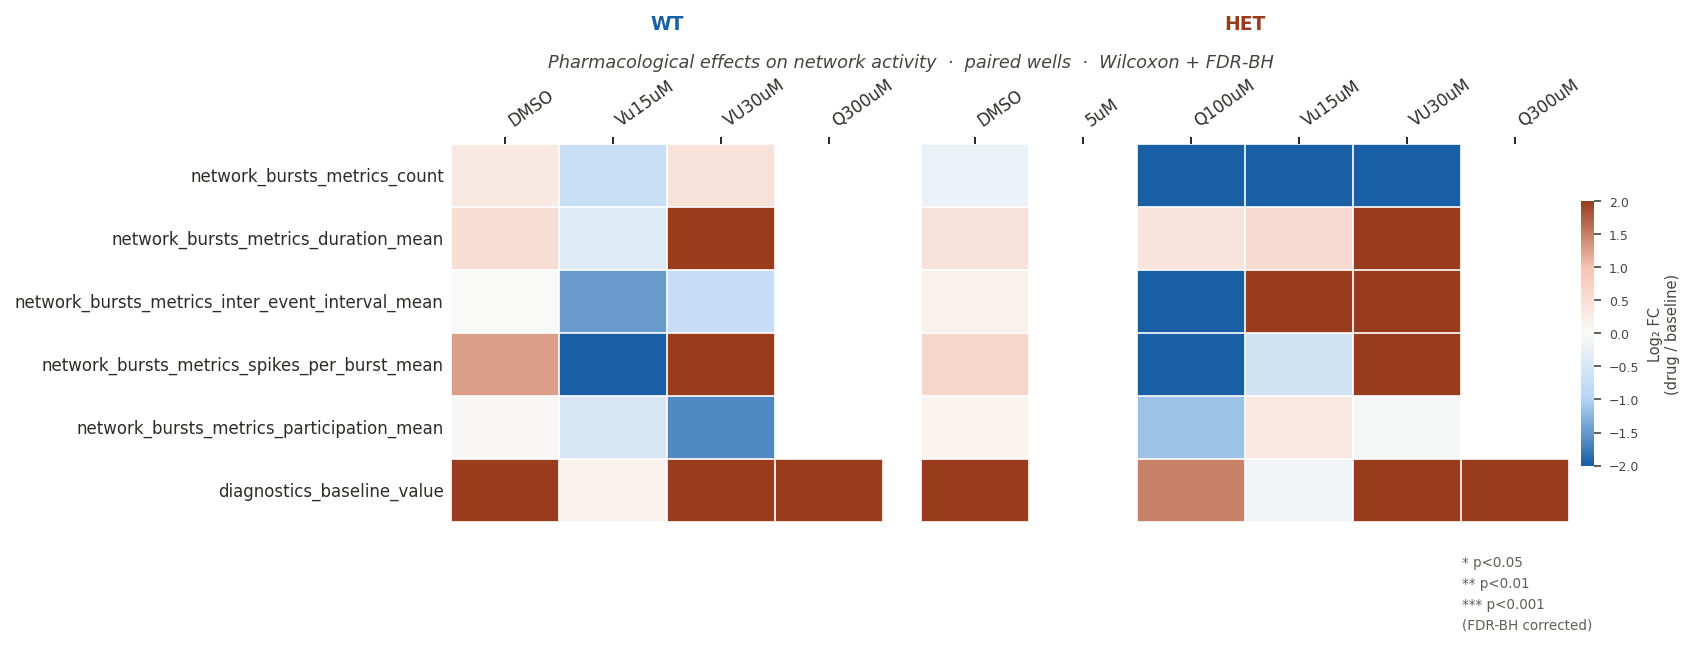


Figure saved: pharma_heatmap_grant_figure.pdf
Stats saved: pharma_heatmap_statistics.csv


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# SETTINGS — add as many metrics as you want here
# =========================================================

metrics_to_run = [
    'network_bursts_metrics_count',
    'network_bursts_metrics_duration_mean',
    'network_bursts_metrics_inter_event_interval_mean',
    'network_bursts_metrics_spikes_per_burst_mean',
    'network_bursts_metrics_participation_mean',
    'diagnostics_baseline_value'

]

# =========================================================
# RUNS
# =========================================================

baseline_runs = [
    108, 109, 111, 112, 114, 115,
    135, 136, 139, 140, 142, 145
]

drug_runs = [
    119, 121, 123,
    146, 149, 151, 153, 156, 157
]

# =========================================================
# COMPARISONS
# =========================================================

wt_comparisons = [
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Q300uM'),
]

het_comparisons = [
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_5uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Q300uM'),
]

# =========================================================
# PRETTY METRIC LABELS (add yours here)
# =========================================================

metric_labels = {
    'burstlets_metrics_count': 'Burstlet count',
    'network_burst_rate':       'Network burst rate',
    'mean_firing_rate':         'Mean firing rate',
    'isi_mean':                 'ISI (mean)',
    'burst_duration_mean':      'Burst duration',
    'ibi_mean':                 'IBI (mean)',
    'participation_fraction':   'Participation fraction',
    'peak_synchrony':           'Peak synchrony',
    'active_area':              'Active area',
    'spikes_per_burst':         'Spikes / burst',
}

# =========================================================
# COPY DATA
# =========================================================

df = network_assay_df.copy()

df['pair_id'] = (
    df['chip_id'].astype(str) + '_' +
    df['well'].astype(str)
)

# =========================================================
# CORE FUNCTION — returns (log2_fc, p_fdr) per condition
# =========================================================

def compute_matrix(dataframe, metric_col, comparisons):
    """
    For each (baseline_group, drug_group) pair, compute
    median log2 fold-change and FDR-corrected p-value.
    Returns arrays: fc_values, p_values, drug_labels, n_pairs
    """
    plot_df = dataframe.copy()
    plot_df[metric_col] = pd.to_numeric(
        plot_df[metric_col], errors='coerce'
    )
    plot_df = plot_df.dropna(subset=[metric_col])

    fc_list   = []
    p_list    = []
    col_labels = []
    n_list    = []

    for baseline_group, drug_group in comparisons:

        baseline_df = plot_df[
            (plot_df['NeuronType'] == baseline_group) &
            (plot_df['run_id'].isin(baseline_runs))
        ][['pair_id', metric_col]].drop_duplicates('pair_id')

        drug_df = plot_df[
            (plot_df['NeuronType'] == drug_group) &
            (plot_df['run_id'].isin(drug_runs))
        ][['pair_id', metric_col]].drop_duplicates('pair_id')

        merged = baseline_df.merge(
            drug_df, on='pair_id',
            suffixes=('_base', '_drug')
        )

        n = len(merged)
        n_list.append(n)

        # drug label = everything after the genotype prefix
        col_labels.append(drug_group.split('_', 1)[-1])

        if n == 0:
            fc_list.append(np.nan)
            p_list.append(np.nan)
            continue

        x = merged[f'{metric_col}_base'].to_numpy()
        y = merged[f'{metric_col}_drug'].to_numpy()

        # log2 fold-change on medians (robust)
        eps = 1e-9
        fc = np.log2((np.median(y) + eps) / (np.median(x) + eps))
        fc_list.append(fc)

        if n == 1 or np.allclose(x, y):
            p_list.append(np.nan)
        else:
            try:
                _, p = wilcoxon(x, y)
                p_list.append(p)
            except ValueError:
                p_list.append(np.nan)

    # FDR correction across conditions for this metric
    fc_arr = np.array(fc_list)
    p_arr  = np.array(p_list)
    p_fdr  = np.full_like(p_arr, np.nan)

    valid = ~np.isnan(p_arr)
    if valid.sum() > 0:
        _, p_corr, _, _ = multipletests(
            p_arr[valid], method='fdr_bh'
        )
        p_fdr[valid] = p_corr

    return fc_arr, p_fdr, col_labels, n_list


# =========================================================
# BUILD MATRICES
# =========================================================

def build_matrices(dataframe, metrics, comparisons):
    """Returns fc_matrix (n_metrics x n_conditions),
       p_matrix, col_labels, row_labels."""
    fc_rows, p_rows = [], []
    col_labels_ref = None
    row_labels = []

    for metric in metrics:
        if metric not in dataframe.columns:
            print(f'  Skipping missing metric: {metric}')
            continue
        fc, p, col_labels, _ = compute_matrix(
            dataframe, metric, comparisons
        )
        fc_rows.append(fc)
        p_rows.append(p)
        if col_labels_ref is None:
            col_labels_ref = col_labels
        row_labels.append(metric_labels.get(metric, metric))

    return (
        np.array(fc_rows),
        np.array(p_rows),
        col_labels_ref or [],
        row_labels
    )


print('Building WT matrix...')
wt_fc, wt_p, wt_cols, row_labels = build_matrices(
    df, metrics_to_run, wt_comparisons
)

print('Building HET matrix...')
het_fc, het_p, het_cols, _ = build_matrices(
    df, metrics_to_run, het_comparisons
)

# =========================================================
# SIGNIFICANCE ANNOTATION
# =========================================================

def sig_stars(p):
    if np.isnan(p):    return ''
    if p < 0.001:      return '***'
    if p < 0.01:       return '**'
    if p < 0.05:       return '*'
    return ''

# =========================================================
# COLORMAP — blue (decrease) → white → coral (increase)
# =========================================================

cmap = mcolors.LinearSegmentedColormap.from_list(
    'pharma',
    ['#185FA5', '#B5D4F4', '#FAFAF8', '#F5C4B3', '#993C1D'],
    N=256
)
vmax = 2.0  # cap at ±2 log2 FC; adjust if needed

# =========================================================
# FIGURE
# =========================================================

n_metrics = len(row_labels)
n_wt      = len(wt_cols)
n_het     = len(het_cols)

cell_h    = 0.42   # inches per row
cell_w    = 0.72   # inches per column
label_w   = 1.6    # row label column
gap_w     = 0.25   # gap between WT and HET panels
cbar_w    = 0.18
margin_l  = 0.15
margin_r  = 0.25
margin_t  = 0.65
margin_b  = 0.85

fig_w = (margin_l + label_w +
         n_wt  * cell_w + gap_w +
         n_het * cell_w +
         cbar_w + margin_r)
fig_h = margin_t + n_metrics * cell_h + margin_b

fig = plt.figure(figsize=(fig_w, fig_h), dpi=150)

# convert margins to figure fractions
def frac_x(px): return px / fig_w
def frac_y(py): return py / fig_h

ax_wt_l  = frac_x(margin_l + label_w)
ax_het_l = frac_x(margin_l + label_w + n_wt * cell_w + gap_w)
ax_w_wt  = frac_x(n_wt  * cell_w)
ax_w_het = frac_x(n_het * cell_w)
ax_b     = frac_y(margin_b)
ax_h     = frac_y(n_metrics * cell_h)

ax_wt  = fig.add_axes([ax_wt_l,  ax_b, ax_w_wt,  ax_h])
ax_het = fig.add_axes([ax_het_l, ax_b, ax_w_het, ax_h])

cbar_ax = fig.add_axes([
    frac_x(margin_l + label_w + n_wt*cell_w + gap_w + n_het*cell_w + 0.08),
    ax_b + ax_h * 0.15,
    frac_x(cbar_w * 0.5),
    ax_h * 0.7
])

# row labels axis
lax = fig.add_axes([frac_x(margin_l), ax_b, frac_x(label_w - 0.05), ax_h])
lax.axis('off')


def draw_heatmap(ax, fc_matrix, p_matrix, col_labels, title, color):
    n_rows, n_cols = fc_matrix.shape

    im = ax.imshow(
        fc_matrix,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        aspect='auto',
        origin='upper',
        interpolation='none'
    )

    # grid lines
    for i in range(n_rows + 1):
        ax.axhline(i - 0.5, color='white', linewidth=0.8, zorder=3)
    for j in range(n_cols + 1):
        ax.axvline(j - 0.5, color='white', linewidth=0.8, zorder=3)

    # significance stars
    for r in range(n_rows):
        for c in range(n_cols):
            stars = sig_stars(p_matrix[r, c])
            if stars:
                ax.text(
                    c, r, stars,
                    ha='center', va='center',
                    fontsize=7, color='#2C2C2A',
                    fontweight='bold', zorder=4
                )

    # column labels (top)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(
        col_labels, rotation=35, ha='left',
        fontsize=8, color='#2C2C2A'
    )
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')

    # no y ticks (row labels drawn separately)
    ax.set_yticks([])

    # genotype title
    ax.set_title(
        title, fontsize=9, fontweight='bold',
        color=color, pad=22
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    return im


im = draw_heatmap(
    ax_wt,  wt_fc,  wt_p,  wt_cols,
    'WT',   '#185FA5'
)
draw_heatmap(
    ax_het, het_fc, het_p, het_cols,
    'HET',  '#993C1D'
)

# =========================================================
# ROW LABELS
# =========================================================

for i, label in enumerate(row_labels):
    y_frac = 1 - (i + 0.5) / n_metrics
    lax.text(
        1.0, y_frac, label,
        ha='right', va='center',
        fontsize=8, color='#2C2C2A',
        transform=lax.transAxes
    )

# =========================================================
# COLORBAR
# =========================================================

cb = plt.colorbar(im, cax=cbar_ax)
cb.set_label('Log₂ FC\n(drug / baseline)', fontsize=7, color='#444441')
cb.ax.tick_params(labelsize=6, colors='#444441')
cb.outline.set_visible(False)

# =========================================================
# LEGEND — significance
# =========================================================

sig_legend = [
    Patch(facecolor='none', edgecolor='none', label='* p<0.05'),
    Patch(facecolor='none', edgecolor='none', label='** p<0.01'),
    Patch(facecolor='none', edgecolor='none', label='*** p<0.001'),
    Patch(facecolor='none', edgecolor='none', label='(FDR-BH corrected)'),
]

fig.legend(
    handles=sig_legend,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.01),
    fontsize=6.5,
    frameon=False,
    labelcolor='#5F5E5A',
    handlelength=0
)

# =========================================================
# SUPER-TITLE
# =========================================================

fig.text(
    0.5, 0.99,
    'Pharmacological effects on network activity  ·  paired wells  ·  Wilcoxon + FDR-BH',
    ha='center', va='top',
    fontsize=8.5, color='#444441',
    style='italic'
)

# =========================================================
# SAVE
# =========================================================

out_path = 'pharma_heatmap_grant_figure.pdf'
fig.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()

print(f'\nFigure saved: {out_path}')

# =========================================================
# ALSO SAVE STATS TABLE
# =========================================================

rows = []
for genotype, comparisons, fc_mat, p_mat, col_lbls in [
    ('WT',  wt_comparisons,  wt_fc,  wt_p,  wt_cols),
    ('HET', het_comparisons, het_fc, het_p, het_cols),
]:
    for mi, metric in enumerate([
        m for m in metrics_to_run if m in df.columns
    ]):
        for ci, cond in enumerate(col_lbls):
            rows.append({
                'genotype':    genotype,
                'metric':      metric,
                'condition':   cond,
                'log2_fc':     round(fc_mat[mi, ci], 4) if not np.isnan(fc_mat[mi, ci]) else np.nan,
                'p_fdr':       round(p_mat[mi, ci], 4) if not np.isnan(p_mat[mi, ci]) else np.nan,
                'sig':         sig_stars(p_mat[mi, ci]),
            })

pd.DataFrame(rows).to_csv(
    'pharma_heatmap_statistics.csv', index=False
)
print('Stats saved: pharma_heatmap_statistics.csv')

Building WT matrix...
Building HET matrix...


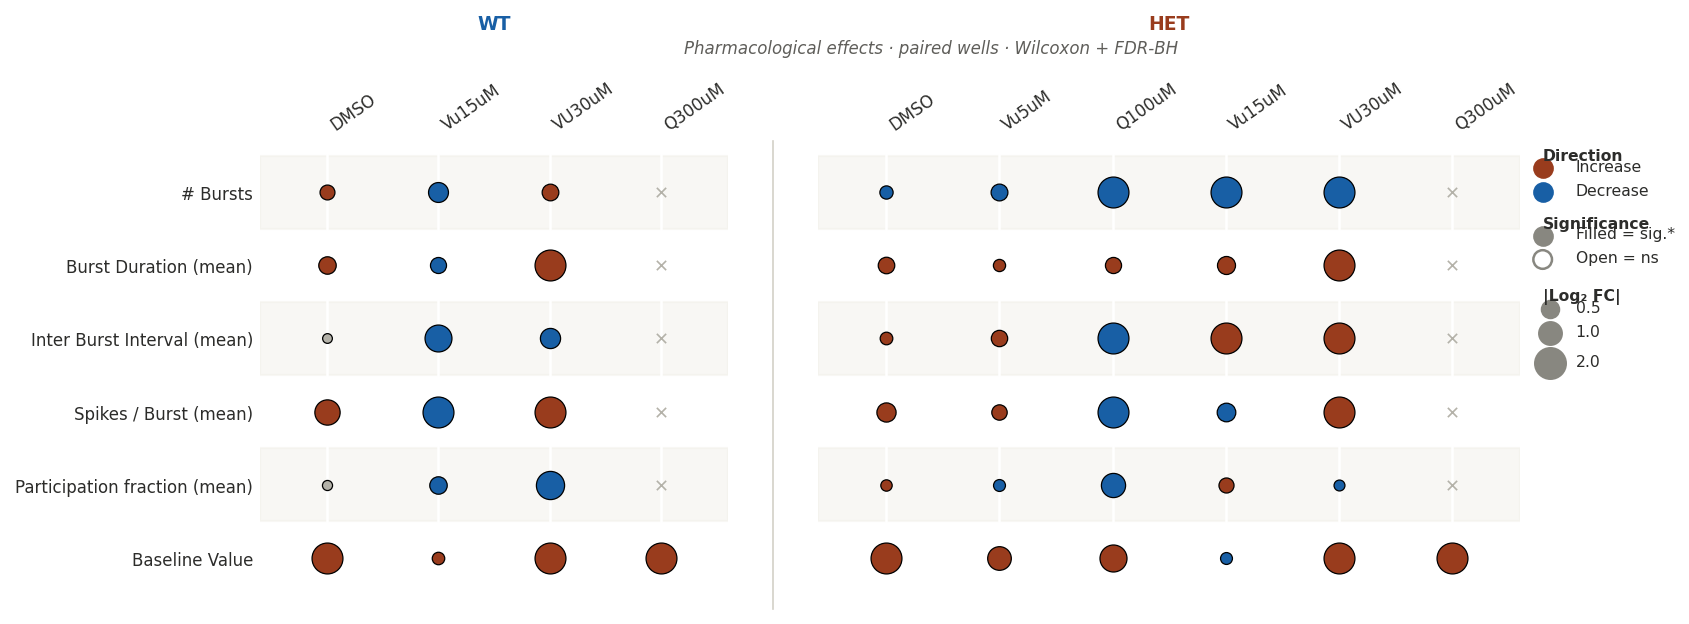


Figure saved: pharma_dotplot_grant_figure.pdf
Stats saved: pharma_dotplot_statistics.csv


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# =========================================================
# SETTINGS
# =========================================================

metrics_to_run = [
    'network_bursts_metrics_count',
    'network_bursts_metrics_duration_mean',
    'network_bursts_metrics_inter_event_interval_mean',
    'network_bursts_metrics_spikes_per_burst_mean',
    'network_bursts_metrics_participation_mean',
    'diagnostics_baseline_value'

]


baseline_runs = [
    108, 109, 111, 112, 114, 115,
    135, 136, 139, 140, 142, 145
]

drug_runs = [
    119, 121, 123,
    146, 149, 151, 153, 156, 157
]

wt_comparisons = [
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Q300uM'),
]

het_comparisons = [
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_Vu5uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Q300uM'),
]

metric_labels = {
    'network_bursts_metrics_count': '# Bursts',
    'network_bursts_metrics_duration_mean': 'Burst Duration (mean)',
    'network_bursts_metrics_inter_event_interval_mean': 'Inter Burst Interval (mean)',
    'network_bursts_metrics_spikes_per_burst_mean': 'Spikes / Burst (mean)',
    'network_bursts_metrics_participation_mean': 'Participation fraction (mean)',
    'diagnostics_baseline_value': 'Baseline Value'
}

# =========================================================
# PREP DATA
# =========================================================

df = network_assay_df.copy()
df['pair_id'] = df['chip_id'].astype(str) + '_' + df['well'].astype(str)

# =========================================================
# COMPUTE MATRIX
# =========================================================

def compute_matrix(dataframe, metric_col, comparisons):
    plot_df = dataframe.copy()
    plot_df[metric_col] = pd.to_numeric(plot_df[metric_col], errors='coerce')
    plot_df = plot_df.dropna(subset=[metric_col])

    fc_list, p_list, col_labels, n_list = [], [], [], []

    for baseline_group, drug_group in comparisons:

        base_df = plot_df[
            (plot_df['NeuronType'] == baseline_group) &
            (plot_df['run_id'].isin(baseline_runs))
        ][['pair_id', metric_col]].drop_duplicates('pair_id')

        drug_df = plot_df[
            (plot_df['NeuronType'] == drug_group) &
            (plot_df['run_id'].isin(drug_runs))
        ][['pair_id', metric_col]].drop_duplicates('pair_id')

        merged = base_df.merge(drug_df, on='pair_id', suffixes=('_base', '_drug'))
        n = len(merged)
        n_list.append(n)
        col_labels.append(drug_group.split('_', 1)[-1])

        if n == 0:
            fc_list.append(np.nan)
            p_list.append(np.nan)
            continue

        x = merged[f'{metric_col}_base'].to_numpy()
        y = merged[f'{metric_col}_drug'].to_numpy()

        eps = 1e-9
        fc = np.log2((np.median(y) + eps) / (np.median(x) + eps))
        fc_list.append(fc)

        if n == 1 or np.allclose(x, y):
            p_list.append(np.nan)
        else:
            try:
                _, p = wilcoxon(x, y)
                p_list.append(p)
            except ValueError:
                p_list.append(np.nan)

    fc_arr = np.array(fc_list)
    p_arr  = np.array(p_list)
    p_fdr  = np.full_like(p_arr, np.nan)

    valid = ~np.isnan(p_arr)
    if valid.sum() > 0:
        _, p_corr, _, _ = multipletests(p_arr[valid], method='fdr_bh')
        p_fdr[valid] = p_corr

    return fc_arr, p_fdr, col_labels, np.array(n_list)


def build_matrices(dataframe, metrics, comparisons):
    fc_rows, p_rows, n_rows = [], [], []
    col_labels_ref = None
    row_labels = []
    valid_metrics = []

    for metric in metrics:
        if metric not in dataframe.columns:
            print(f'  Skipping missing metric: {metric}')
            continue
        fc, p, col_labels, n = compute_matrix(dataframe, metric, comparisons)
        fc_rows.append(fc)
        p_rows.append(p)
        n_rows.append(n)
        if col_labels_ref is None:
            col_labels_ref = col_labels
        row_labels.append(metric_labels.get(metric, metric))
        valid_metrics.append(metric)

    return (
        np.array(fc_rows),
        np.array(p_rows),
        np.array(n_rows),
        col_labels_ref or [],
        row_labels
    )


print('Building WT matrix...')
wt_fc, wt_p, wt_n, wt_cols, row_labels = build_matrices(df, metrics_to_run, wt_comparisons)

print('Building HET matrix...')
het_fc, het_p, het_n, het_cols, _ = build_matrices(df, metrics_to_run, het_comparisons)

# =========================================================
# SIGNIFICANCE
# =========================================================

def sig_stars(p):
    if np.isnan(p):  return ''
    if p < 0.001:    return '***'
    if p < 0.01:     return '**'
    if p < 0.05:     return '*'
    return 'ns'

# =========================================================
# DOT PLOT DRAWING
# =========================================================

# Dot size maps to |log2 FC|, capped at vmax
# Color maps to direction: blue = decrease, coral = increase
# Filled circle = significant; open circle = ns

VMAX       = 2.0        # log2 FC cap for size scaling
SIZE_MIN   = 20         # pt² for FC near 0
SIZE_MAX   = 220        # pt² for FC at VMAX
COL_UP     = '#993C1D'  # coral — increase
COL_DOWN   = '#185FA5'  # blue  — decrease
COL_ZERO   = '#B4B2A9'  # gray  — negligible / nan

def fc_to_size(fc_arr):
    """Map |log2 FC| → marker area in pt²."""
    abs_fc = np.abs(np.where(np.isnan(fc_arr), 0, fc_arr))
    t = np.clip(abs_fc / VMAX, 0, 1)
    return SIZE_MIN + t * (SIZE_MAX - SIZE_MIN)

def fc_to_color(fc_arr):
    colors = []
    for v in fc_arr:
        if np.isnan(v) or abs(v) < 0.05:
            colors.append(COL_ZERO)
        elif v > 0:
            colors.append(COL_UP)
        else:
            colors.append(COL_DOWN)
    return colors


def draw_dotmap(ax, fc_matrix, p_matrix, n_matrix,
                col_labels, row_labels, title, title_color):
    """
    fc_matrix : (n_metrics, n_conditions)
    Each dot: position = (col, row), size = |FC|, color = direction,
    filled = significant, open = ns.
    Stars printed above significant dots.
    """
    n_rows, n_cols = fc_matrix.shape

    # ---- alternating row bands for readability ----
    for r in range(n_rows):
        if r % 2 == 0:
            ax.axhspan(r - 0.5, r + 0.5,
                       color='#F1EFE8', alpha=0.45, zorder=0)

    # ---- draw dots row by row ----
    for r in range(n_rows):
        fc_row = fc_matrix[r]
        p_row  = p_matrix[r]
        n_row  = n_matrix[r]

        sizes  = fc_to_size(fc_row)
        colors = fc_to_color(fc_row)
        cols_x = np.arange(n_cols, dtype=float)

        for c in range(n_cols):
            fc_val = fc_row[c]
            p_val  = p_row[c]
            s      = sizes[c]
            col    = colors[c]
            stars  = sig_stars(p_val)
            is_sig = stars not in ('ns', '')

            if np.isnan(fc_val):
                # tiny gray X for missing data
                ax.scatter(c, r, marker='x', s=20,
                           color='#B4B2A9', linewidths=0.8,
                           zorder=3)
                continue

            # all dots filled, black outline
            ax.scatter(c, r, s=s, color=col,
                       edgecolors='black', linewidths=0.6,
                       zorder=3)

            # stars only for significant
            if is_sig:
                ax.text(c, r + 0.38, stars,
                        ha='center', va='bottom',
                        fontsize=6.5, color='#2C2C2A',
                        fontweight='bold', zorder=4)

    # ---- axes ----
    ax.set_xlim(-0.6, n_cols - 0.4)
    ax.set_ylim(-0.7, n_rows - 0.3)
    ax.invert_yaxis()

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels, rotation=35, ha='left',
                       fontsize=8, color='#2C2C2A')
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')

    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8, color='#2C2C2A')

    ax.set_title(title, fontsize=9, fontweight='bold',
                 color=title_color, pad=24)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)
    ax.grid(axis='x', color='white', linewidth=1.2, zorder=1)


# =========================================================
# FIGURE LAYOUT
# =========================================================

n_metrics = len(row_labels)
n_wt      = len(wt_cols)
n_het     = len(het_cols)

cell_h  = 0.52
cell_w  = 0.78
label_w = 1.55
gap_w   = 0.6
margin_l = 0.1
margin_r = 2.2   # room for legend
margin_t = 0.7
margin_b = 0.3

fig_w = margin_l + label_w + n_wt*cell_w + gap_w + n_het*cell_w + margin_r
fig_h = margin_t + n_metrics*cell_h + margin_b

fig = plt.figure(figsize=(fig_w, fig_h), dpi=150)

def fx(x): return x / fig_w
def fy(y): return y / fig_h

ax_b  = fy(margin_b)
ax_h  = fy(n_metrics * cell_h)

ax_wt = fig.add_axes([
    fx(margin_l + label_w),
    ax_b,
    fx(n_wt * cell_w),
    ax_h
])

ax_het = fig.add_axes([
    fx(margin_l + label_w + n_wt*cell_w + gap_w),
    ax_b,
    fx(n_het * cell_w),
    ax_h
])

draw_dotmap(ax_wt,  wt_fc,  wt_p,  wt_n,
            wt_cols,  row_labels, 'WT',  '#185FA5')

draw_dotmap(ax_het, het_fc, het_p, het_n,
            het_cols, row_labels, 'HET', '#993C1D')

# hide duplicate y-axis labels on HET panel
ax_het.set_yticklabels([])

# vertical divider between panels
fig.add_artist(plt.Line2D(
    [fx(margin_l + label_w + n_wt*cell_w + gap_w*0.5)] * 2,
    [ax_b, ax_b + ax_h],
    color='#D3D1C7', linewidth=0.8, transform=fig.transFigure
))

# =========================================================
# LEGEND
# =========================================================

legend_x = fx(margin_l + label_w + n_wt*cell_w + gap_w + n_het*cell_w + 0.15)
legend_y  = ax_b + ax_h

# -- direction --
fig.text(legend_x, legend_y - fy(0.05),
         'Direction', fontsize=7.5, fontweight='bold',
         color='#2C2C2A', va='top')

for label, col, offset in [
    ('Increase', COL_UP,   0.18),
    ('Decrease', COL_DOWN, 0.34),
]:
    ax_tmp = fig.add_axes([legend_x, legend_y - fy(offset), 0.001, 0.001])
    ax_tmp.scatter([0], [0], s=80, color=col, clip_on=False,
                   transform=ax_tmp.transAxes)
    ax_tmp.axis('off')
    fig.text(legend_x + fx(0.22), legend_y - fy(offset) + fy(0.01),
             label, fontsize=7.5, color='#2C2C2A', va='center')

# -- significance --
fig.text(legend_x, legend_y - fy(0.50),
         'Significance', fontsize=7.5, fontweight='bold',
         color='#2C2C2A', va='top')

ax_sig1 = fig.add_axes([legend_x, legend_y - fy(0.63), 0.001, 0.001])
ax_sig1.scatter([0], [0], s=80, color='#888780', clip_on=False,
                transform=ax_sig1.transAxes)
ax_sig1.axis('off')
fig.text(legend_x + fx(0.22), legend_y - fy(0.63) + fy(0.01),
         'Filled = sig.*', fontsize=7.5, color='#2C2C2A', va='center')

ax_sig2 = fig.add_axes([legend_x, legend_y - fy(0.79), 0.001, 0.001])
ax_sig2.scatter([0], [0], s=80, facecolors='none',
                edgecolors='#888780', linewidths=1.2,
                clip_on=False, transform=ax_sig2.transAxes)
ax_sig2.axis('off')
fig.text(legend_x + fx(0.22), legend_y - fy(0.79) + fy(0.01),
         'Open = ns', fontsize=7.5, color='#2C2C2A', va='center')

# -- size scale --
fig.text(legend_x, legend_y - fy(0.98),
         '|Log₂ FC|', fontsize=7.5, fontweight='bold',
         color='#2C2C2A', va='top')

for fc_demo, offset in [(0.5, 1.12), (1.0, 1.28), (2.0, 1.48)]:
    s = fc_to_size(np.array([fc_demo]))[0]
    ax_s = fig.add_axes([legend_x + fx(0.05),
                         legend_y - fy(offset), 0.001, 0.001])
    ax_s.scatter([0], [0], s=s, color='#888780', clip_on=False,
                 transform=ax_s.transAxes)
    ax_s.axis('off')
    fig.text(legend_x + fx(0.22), legend_y - fy(offset) + fy(0.01),
             f'{fc_demo:.1f}', fontsize=7.5, color='#2C2C2A', va='center')

# =========================================================
# SUPER TITLE
# =========================================================

fig.text(
    0.5, 0.995,
    'Pharmacological effects · paired wells · Wilcoxon + FDR-BH',
    ha='center', va='top', fontsize=8, color='#5F5E5A', style='italic'
)

# =========================================================
# SAVE
# =========================================================

out_path = 'pharma_dotplot_grant_figure.pdf'
fig.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'\nFigure saved: {out_path}')

# =========================================================
# STATS TABLE
# =========================================================

rows = []
valid_metrics = [m for m in metrics_to_run if m in df.columns]

for genotype, cols, fc_mat, p_mat in [
    ('WT',  wt_cols,  wt_fc,  wt_p),
    ('HET', het_cols, het_fc, het_p),
]:
    for mi, metric in enumerate(valid_metrics):
        for ci, cond in enumerate(cols):
            rows.append({
                'genotype':  genotype,
                'metric':    metric,
                'condition': cond,
                'log2_fc':   round(fc_mat[mi, ci], 4) if not np.isnan(fc_mat[mi, ci]) else np.nan,
                'p_fdr':     round(p_mat[mi, ci], 4)  if not np.isnan(p_mat[mi, ci])  else np.nan,
                'sig':       sig_stars(p_mat[mi, ci]),
            })

pd.DataFrame(rows).to_csv('pharma_dotplot_statistics.csv', index=False)
print('Stats saved: pharma_dotplot_statistics.csv')

In [ ]:
# Supports:
# (ID, Well)       -> remove all DIVs for that well
# (ID, Well, DIV)  -> remove only that specific DIV
to_remove = [
    ('M07420', 'well005'),
    ('M07039', 'well004'),
    ('M07420', 'well002', 27),
    ('M07420', 'well004', 8),
]

mask_remove = pd.Series(False, index=network_assay_df.index)

for item in to_remove:
    if len(item) == 2:
        id_, well = item
        cond = (network_assay_df['ID'] == id_) & (network_assay_df['Well'] == well)
    elif len(item) == 3:
        id_, well, div = item
        cond = (
            (network_assay_df['ID'] == id_) &
            (network_assay_df['Well'] == well) &
            (network_assay_df['DIV'] == div)
        )
    else:
        raise ValueError(f"Invalid tuple format: {item}. Use (ID, Well) or (ID, Well, DIV).")

    mask_remove |= cond

removed_rows = int(mask_remove.sum())
network_assay_df = network_assay_df.loc[~mask_remove].copy()

print(f"Removed rows: {removed_rows}")
print(f"Remaining rows: {len(network_assay_df)}")


In [ ]:
palette = {'WT': '#4C72B0', 'HET': '#D55E00', 'KI': '#A63226',
               'MxWT': '#4C72B0', 'FxHET': '#D55E00', 'MxHEMI': '#A63226'}
markers = ['o','s','d','*','^']
colors=[]
unique_genotypes = network_assay_df['NeuronType'].unique()
for i, genotype in enumerate(unique_genotypes):
    colors.append(palette[genotype])
order =['MxWT','FxHET','MxHEMI']


In [ ]:
import sys
sys.path.append("/pscratch/sd/m/mpatil1/MEA_Analysis/IPNAnalysis")
import meaplotter
import importlib
importlib.reload(meaplotter)
viz = meaplotter.MEAPlotter(
    group_order=order,
    palette=palette
)

In [ ]:
network_assay_df['NeuronType'].unique()

In [ ]:
# Remove all rows where DIV == 5 from the network dataframe
before_rows = len(network_assay_df)
network_assay_df = network_assay_df.loc[network_assay_df['DIV'] != 5].copy()
removed_rows = before_rows - len(network_assay_df)

print(f"Removed DIV 5 rows: {removed_rows}")
print(f"Remaining rows: {len(network_assay_df)}")

In [ ]:
columns_to_plot = [ 'bl_burst_peak_mean', 'bl_count', 'bl_duration_cv', 'bl_duration_mean',
       'bl_duration_std', 'bl_durations', 'bl_ibi_cv', 'bl_ibi_mean',
       'bl_ibi_std', 'bl_intensity', 'bl_intensity_mean',
       'bl_participation_mean', 'bl_peak_sync_mean', 'bl_peaks', 'bl_rate_hz',
       'bl_spikes_mean', 'bl_sync_energy', 'diag_adaptive_bin_ms',
       'diag_baseline_value', 'diag_biological_isi_s',
       'diag_burstlet_merge_gap_s', 'diag_merge_floor', 'diag_n_units',
       'diag_network_merge_gap_s', 'diag_sigma_fast_bins',
       'diag_sigma_slow_bins', 'diag_smoothing_sigma_fast_bins',
       'diag_smoothing_sigma_slow_bins', 'diag_spread_mad',
       'diag_threshold_value', 'n_units', 'nb_burst_peak_mean', 'nb_count',
       'nb_duration_cv', 'nb_duration_mean', 'nb_duration_std', 'nb_durations',
       'nb_fragment_list', 'nb_fragment_mean', 'nb_ibi_cv', 'nb_ibi_mean',
       'nb_ibi_std', 'nb_intensity', 'nb_intensity_mean',
       'nb_participation_mean', 'nb_peak_sync_mean', 'nb_peaks', 'nb_rate_hz',
       'nb_spikes_mean', 'nb_sync_energy', 'sb_burst_peak_mean', 'sb_count',
       'sb_duration_cv', 'sb_duration_mean', 'sb_duration_std', 'sb_durations',
       'sb_ibi_cv', 'sb_ibi_mean', 'sb_ibi_std', 'sb_intensity',
       'sb_intensity_mean', 'sb_participation_mean', 'sb_peak_sync_mean',
       'sb_peaks', 'sb_rate_hz', 'sb_spikes_mean', 'sb_sync_energy'
       ]
PATH = "/pscratch/sd/m/mpatil1/MEA_Analysis/AnalyzedData/CDKL5_T1/figures"
for col in columns_to_plot:
  
  try:
      ax = viz.plot_line_sem_by_div(
          network_assay_df,
          div_col="DIV",
          group_col="NeuronType",
          y=col,
          title=f"{col}",
          show_legend=False,
          fig_width = 2.5,
          aspect = 0.8
      )
      ax.get_figure().savefig(f"{PATH}/{col}.svg", dpi=300,format="svg") 
      stat_df = viz.calculate_stats_by_div_welch(network_assay_df, div_col="DIV", group_col="NeuronType", y=col, group_order=order)
      stat_df.to_csv(f"{PATH}/{col}_stats.csv", index=False)
  except Exception as e:
      print(f"Could not plot {col}: {e}")


Skipping WT_Q300uM (not enough pairs)

WT Pharmacology Comparisons

  baseline       drug  n_pairs  baseline_mean  drug_mean  p_uncorrected  \
0       WT    WT_DMSO        6      66.000000       71.0        0.34375   
1       WT  WT_Vu15uM        5      71.600000       32.2        0.31250   
2       WT  WT_VU30uM        3      75.333333       73.0        1.00000   

      p_fdr  significant  
0  0.515625        False  
1  0.515625        False  
2  1.000000        False  


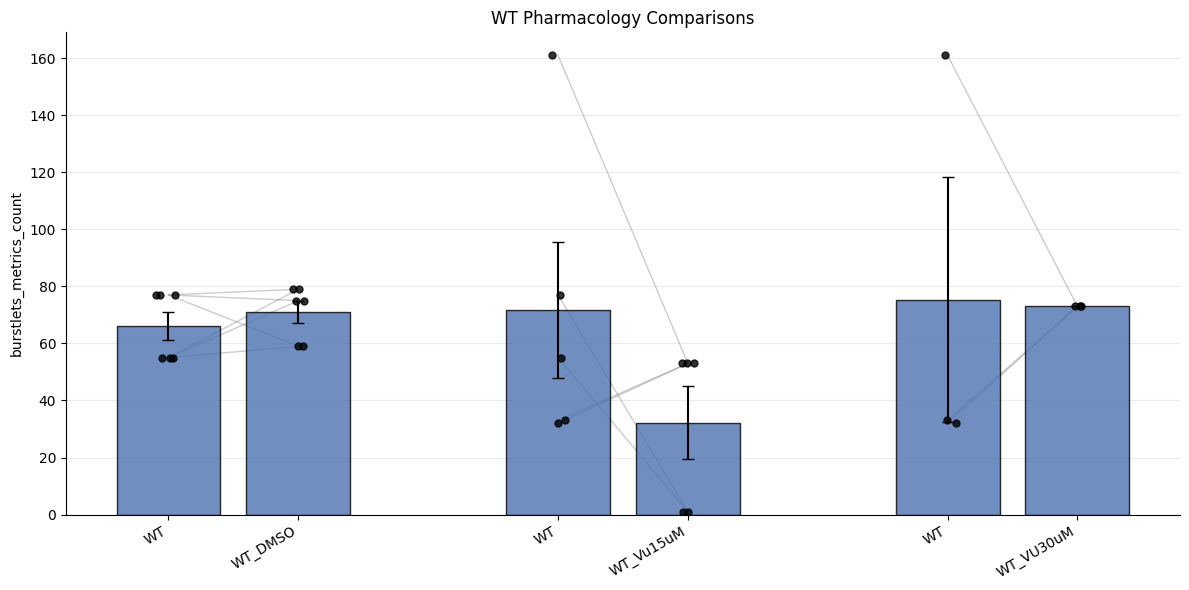

Skipping HET_Q300uM (not enough pairs)

HET Pharmacology Comparisons

  baseline        drug  n_pairs  baseline_mean  drug_mean  p_uncorrected  \
0      HET    HET_DMSO        8     162.250000      144.0         0.3125   
1      HET     HET_5uM        2      88.000000       81.0         1.0000   
2      HET  HET_Q100uM        2      87.500000        1.0         0.5000   
3      HET  HET_Vu15uM        2     187.000000        2.0         0.5000   
4      HET  HET_VU30uM        3      78.666667       19.0         0.2500   

   p_fdr  significant  
0  0.625        False  
1  1.000        False  
2  0.625        False  
3  0.625        False  
4  0.625        False  


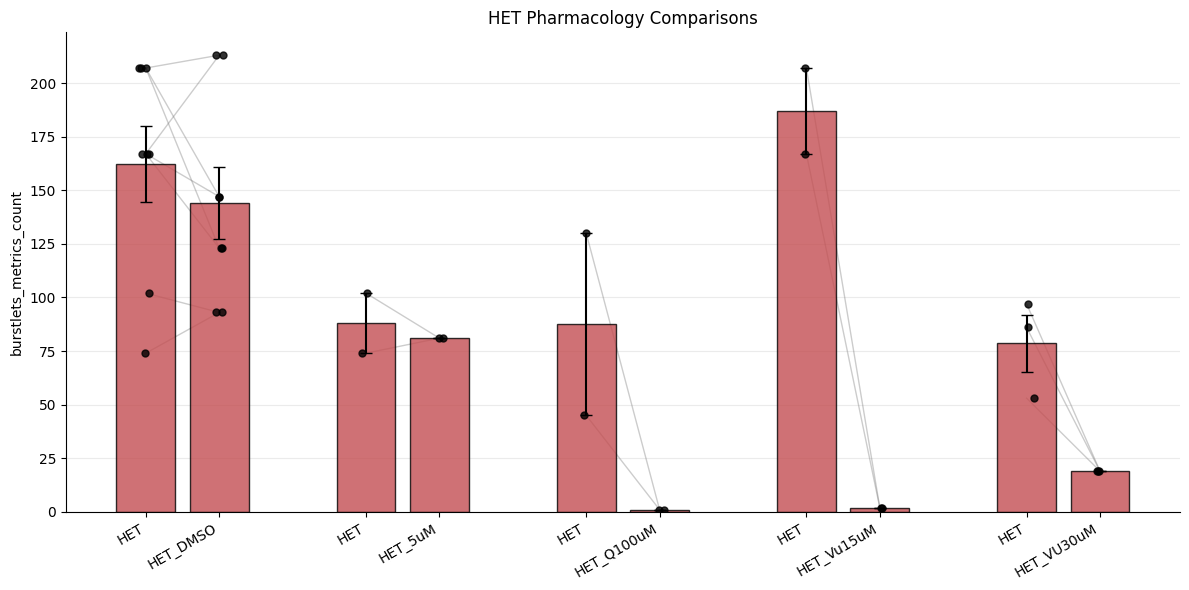

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# =========================================================
# SETTINGS
# =========================================================

metric_col = 'burstlets_metrics_count'

# =========================================================
# CREATE PAIR ID
# =========================================================

df = network_assay_df.copy()

df['pair_id'] = (
    df['chip_id'].astype(str) + '_' +
    df['well'].astype(str)
)

# =========================================================
# KEEP NEEDED COLUMNS
# =========================================================

df = df[
    [
        'pair_id',
        'NeuronType',
        metric_col
    ]
].copy()

df[metric_col] = pd.to_numeric(
    df[metric_col],
    errors='coerce'
)

df = df.dropna(subset=[metric_col])

# =========================================================
# DEFINE COMPARISONS
# =========================================================

wt_comparisons = [
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Q300uM'),
]

het_comparisons = [
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_5uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Q300uM'),
]

# =========================================================
# FUNCTION
# =========================================================

def paired_test_and_plot(comparisons, title):

    results = []

    fig, ax = plt.subplots(figsize=(12, 6))

    plot_data = []

    xpos = []
    labels = []

    current_x = 0

    rng = np.random.default_rng(42)

    for baseline_group, drug_group in comparisons:

        # -------------------------------------------------
        # BASELINE
        # -------------------------------------------------

        baseline_df = df[
            df['NeuronType'] == baseline_group
        ][['pair_id', metric_col]]

        drug_df = df[
            df['NeuronType'] == drug_group
        ][['pair_id', metric_col]]

        # -------------------------------------------------
        # MERGE PAIRED DATA
        # -------------------------------------------------

        merged = baseline_df.merge(
            drug_df,
            on='pair_id',
            suffixes=('_baseline', '_drug')
        )

        if len(merged) < 2:
            print(f'Skipping {drug_group} (not enough pairs)')
            continue

        x = merged[f'{metric_col}_baseline'].to_numpy()
        y = merged[f'{metric_col}_drug'].to_numpy()

        # -------------------------------------------------
        # WILCOXON TEST
        # -------------------------------------------------

        stat, p = wilcoxon(x, y)

        results.append({
            'baseline': baseline_group,
            'drug': drug_group,
            'n_pairs': len(merged),
            'baseline_mean': np.mean(x),
            'drug_mean': np.mean(y),
            'p_uncorrected': p
        })

        # -------------------------------------------------
        # STORE FOR PLOTTING
        # -------------------------------------------------

        plot_data.append(x)
        plot_data.append(y)

        xpos.extend([current_x, current_x + 1])

        labels.extend([
            baseline_group,
            drug_group
        ])

        # -------------------------------------------------
        # PAIRED LINES
        # -------------------------------------------------

        for i in range(len(x)):

            ax.plot(
                [current_x, current_x + 1],
                [x[i], y[i]],
                color='gray',
                alpha=0.4,
                linewidth=1
            )

        current_x += 3

    # =====================================================
    # MULTIPLE COMPARISON CORRECTION
    # =====================================================

    results_df = pd.DataFrame(results)

    reject, p_fdr, _, _ = multipletests(
        results_df['p_uncorrected'],
        method='fdr_bh'
    )

    results_df['p_fdr'] = p_fdr
    results_df['significant'] = reject

    print('\n================================================')
    print(title)
    print('================================================\n')

    print(results_df)

    # =====================================================
    # PLOT BARS
    # =====================================================

    means = [np.mean(v) for v in plot_data]
    sems = [np.std(v, ddof=1)/np.sqrt(len(v)) for v in plot_data]

    colors = []

    for label in labels:

        if label.startswith('WT'):
            colors.append('#4C72B0')

        else:
            colors.append('#C44E52')

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=4,
        color=colors,
        edgecolor='black',
        alpha=0.8,
        zorder=2
    )

    # =====================================================
    # RAW POINTS
    # =====================================================

    for x0, values in zip(xpos, plot_data):

        jitter = rng.normal(0, 0.05, size=len(values))

        ax.scatter(
            np.full(len(values), x0) + jitter,
            values,
            color='black',
            s=25,
            alpha=0.8,
            zorder=3
        )

    # =====================================================
    # FORMAT
    # =====================================================

    ax.set_xticks(xpos)

    ax.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax.set_ylabel(metric_col)

    ax.set_title(title)

    ax.grid(axis='y', alpha=0.25)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# =========================================================
# RUN
# =========================================================

paired_test_and_plot(
    wt_comparisons,
    'WT Pharmacology Comparisons'
)

paired_test_and_plot(
    het_comparisons,
    'HET Pharmacology Comparisons'
)

In [21]:
subset.columns

Index(['json_path', 'project', 'date', 'chip_id', 'run_id', 'well',
       'NeuronType', 'burstlets_metrics_count', 'burstlets_metrics_rate',
       'burstlets_metrics_duration_mean',
       ...
       'Unnamed: 987', 'Unnamed: 988', 'Unnamed: 989', 'Unnamed: 990',
       'Unnamed: 991', 'Unnamed: 992', 'Unnamed: 993', 'Unnamed: 994',
       'Unnamed: 995', 'A1'],
      dtype='object', length=997)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# SETTINGS
# =========================================================

metrics_to_run = [
    'network_bursts_metrics_count',
    'network_bursts_metrics_duration_mean',
    'network_bursts_metrics_inter_event_interval_mean',
    'network_bursts_metrics_spikes_per_burst_mean'



    # 'network_burst_rate',
    # 'mean_firing_rate',
    # 'isi_mean',
]

# =========================================================
# BASELINE (GREEN) RUNS
# =========================================================

baseline_runs = [
    108, 109, 111, 112, 114, 115,
    135, 136, 139, 140, 142, 145
]

# =========================================================
# DRUG (YELLOW) RUNS
# =========================================================

drug_runs = [
    119, 121, 123,
    146, 149, 151, 153, 156, 157
]

# =========================================================
# COMPARISONS
# =========================================================

wt_comparisons = [
    ('WT', 'WT_DMSO'),
    ('WT', 'WT_Vu15uM'),
    ('WT', 'WT_VU30uM'),
    ('WT', 'WT_Q300uM'),
]

het_comparisons = [
    ('HET', 'HET_DMSO'),
    ('HET', 'HET_5uM'),
    ('HET', 'HET_Q100uM'),
    ('HET', 'HET_Vu15uM'),
    ('HET', 'HET_VU30uM'),
    ('HET', 'HET_Q300uM'),
]

# =========================================================
# COPY DATA
# =========================================================

df = network_assay_df.copy()

# =========================================================
# CREATE PAIR ID
# =========================================================

df['pair_id'] = (
    df['chip_id'].astype(str) + '_' +
    df['well'].astype(str)
)

# =========================================================
# PDF OUTPUT
# =========================================================

pdf_path = 'paired_pharmacology_analysis.pdf'

pdf = PdfPages(pdf_path)

# =========================================================
# FUNCTION
# =========================================================

def paired_test_and_plot(
    dataframe,
    metric_col,
    comparisons,
    title
):

    # -----------------------------------------------------
    # CLEAN
    # -----------------------------------------------------

    plot_df = dataframe.copy()

    plot_df[metric_col] = pd.to_numeric(
        plot_df[metric_col],
        errors='coerce'
    )

    plot_df = plot_df.dropna(
        subset=[metric_col]
    )

    # =====================================================
    # FIGURE
    # =====================================================

    fig, ax = plt.subplots(figsize=(14, 6))

    results = []

    plot_data = []

    xpos = []

    labels = []

    current_x = 0

    rng = np.random.default_rng(42)

    # =====================================================
    # LOOP
    # =====================================================

    for baseline_group, drug_group in comparisons:

        # -------------------------------------------------
        # BASELINE
        # -------------------------------------------------

        baseline_df = plot_df[
            (
                plot_df['NeuronType'] == baseline_group
            ) &
            (
                plot_df['run_id'].isin(
                    baseline_runs
                )
            )
        ][
            ['pair_id', metric_col]
        ].copy()

        # -------------------------------------------------
        # DRUG
        # -------------------------------------------------

        drug_df = plot_df[
            (
                plot_df['NeuronType'] == drug_group
            ) &
            (
                plot_df['run_id'].isin(
                    drug_runs
                )
            )
        ][
            ['pair_id', metric_col]
        ].copy()

        # -------------------------------------------------
        # REMOVE DUPLICATES
        # -------------------------------------------------

        baseline_df = baseline_df.drop_duplicates(
            subset='pair_id'
        )

        drug_df = drug_df.drop_duplicates(
            subset='pair_id'
        )

        # -------------------------------------------------
        # MERGE
        # -------------------------------------------------

        merged = baseline_df.merge(
            drug_df,
            on='pair_id',
            suffixes=(
                '_baseline',
                '_drug'
            )
        )

        print('\n----------------------------------')
        print(f'{metric_col}')
        print(f'{baseline_group} vs {drug_group}')
        print(f'Pairs: {len(merged)}')

        if len(merged) == 0:
            print('Skipping: no matched pairs')
            continue

        # -------------------------------------------------
        # EXTRACT VALUES
        # -------------------------------------------------

        x = merged[
            f'{metric_col}_baseline'
        ].to_numpy()

        y = merged[
            f'{metric_col}_drug'
        ].to_numpy()

        # -------------------------------------------------
        # STATS
        # -------------------------------------------------

        if len(x) == 1:

            stat = np.nan
            p = np.nan

        elif np.allclose(x, y):

            stat = np.nan
            p = 1.0

        else:

            try:

                stat, p = wilcoxon(x, y)

            except ValueError:

                stat = np.nan
                p = np.nan

        # -------------------------------------------------
        # STORE RESULTS
        # -------------------------------------------------

        results.append({
            'metric': metric_col,
            'baseline': baseline_group,
            'drug': drug_group,
            'n_pairs': len(merged),
            'baseline_mean': np.mean(x),
            'drug_mean': np.mean(y),
            'p_uncorrected': p
        })

        # -------------------------------------------------
        # STORE FOR PLOTTING
        # -------------------------------------------------

        plot_data.append(x)
        plot_data.append(y)

        xpos.extend([
            current_x,
            current_x + 1
        ])

        labels.extend([
            baseline_group,
            drug_group
        ])

        # -------------------------------------------------
        # PAIRED LINES
        # -------------------------------------------------

        for i in range(len(x)):

            ax.plot(
                [current_x, current_x + 1],
                [x[i], y[i]],
                color='gray',
                linewidth=1,
                alpha=0.45,
                zorder=1
            )

        current_x += 3

    # =====================================================
    # RESULTS TABLE
    # =====================================================

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:

        valid_p = results_df[
            'p_uncorrected'
        ].notna()

        if valid_p.sum() > 0:

            reject, p_fdr, _, _ = multipletests(
                results_df.loc[
                    valid_p,
                    'p_uncorrected'
                ],
                method='fdr_bh'
            )

            results_df.loc[
                valid_p,
                'p_fdr'
            ] = p_fdr

            results_df.loc[
                valid_p,
                'significant'
            ] = reject

    print('\n======================================')
    print(title)
    print(metric_col)
    print('======================================\n')

    print(results_df)

    # =====================================================
    # BAR PLOT
    # =====================================================

    means = [
        np.mean(v)
        for v in plot_data
    ]

    sems = [
        np.std(v, ddof=1) / np.sqrt(len(v))
        if len(v) > 1 else 0
        for v in plot_data
    ]

    # -----------------------------------------------------
    # COLORS
    # -----------------------------------------------------

    colors = []

    for label in labels:

        if label.startswith('WT'):
            colors.append('#4C72B0')

        else:
            colors.append('#C44E52')

    # -----------------------------------------------------
    # BARS
    # -----------------------------------------------------

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=4,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.82,
        zorder=2
    )

    # =====================================================
    # RAW POINTS
    # =====================================================

    for x0, values in zip(
        xpos,
        plot_data
    ):

        jitter = rng.normal(
            0,
            0.05,
            size=len(values)
        )

        ax.scatter(
            np.full(len(values), x0) + jitter,
            values,
            color='black',
            s=28,
            alpha=0.85,
            zorder=3
        )

    # =====================================================
    # FORMATTING
    # =====================================================

    ax.set_xticks(xpos)

    ax.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax.set_ylabel(metric_col)

    ax.set_title(
        f'{title}\n{metric_col}',
        fontsize=14,
        fontweight='bold'
    )

    ax.grid(
        axis='y',
        alpha=0.25
    )

    ax.spines['top'].set_visible(False)

    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # =====================================================
    # SAVE TO PDF
    # =====================================================

    pdf.savefig(fig)

    plt.close(fig)

    return results_df

# =========================================================
# RUN ALL METRICS
# =========================================================

all_results = []

for metric in metrics_to_run:

    if metric not in df.columns:

        print(f'Skipping missing metric: {metric}')
        continue

    # -----------------------------------------------------
    # WT
    # -----------------------------------------------------

    wt_results = paired_test_and_plot(
        dataframe=df,
        metric_col=metric,
        comparisons=wt_comparisons,
        title='WT Pharmacology Comparisons'
    )

    wt_results['family'] = 'WT'

    all_results.append(wt_results)

    # -----------------------------------------------------
    # HET
    # -----------------------------------------------------

    het_results = paired_test_and_plot(
        dataframe=df,
        metric_col=metric,
        comparisons=het_comparisons,
        title='HET Pharmacology Comparisons'
    )

    het_results['family'] = 'HET'

    all_results.append(het_results)

# =========================================================
# SAVE RESULTS TABLE
# =========================================================

if len(all_results) > 0:

    final_results = pd.concat(
        all_results,
        ignore_index=True
    )

    final_results.to_csv(
        'paired_pharmacology_statistics.csv',
        index=False
    )

# =========================================================
# CLOSE PDF
# =========================================================

pdf.close()

print('\n========================================')
print('Analysis complete.')
print(f'PDF saved: {pdf_path}')
print('Statistics saved: paired_pharmacology_statistics.csv')
print('========================================')


----------------------------------
network_bursts_metrics_count
WT vs WT_DMSO
Pairs: 1

----------------------------------
network_bursts_metrics_count
WT vs WT_Vu15uM
Pairs: 2

----------------------------------
network_bursts_metrics_count
WT vs WT_VU30uM
Pairs: 1

----------------------------------
network_bursts_metrics_count
WT vs WT_Q300uM
Pairs: 0
Skipping: no matched pairs

WT Pharmacology Comparisons
network_bursts_metrics_count

                         metric baseline       drug  n_pairs  baseline_mean  \
0  network_bursts_metrics_count       WT    WT_DMSO        1           54.0   
1  network_bursts_metrics_count       WT  WT_Vu15uM        2           41.0   
2  network_bursts_metrics_count       WT  WT_VU30uM        1           28.0   

   drug_mean  p_uncorrected  p_fdr significant  
0       67.0            NaN    NaN         NaN  
1       25.0            1.0    1.0       False  
2       38.0            NaN    NaN         NaN  

----------------------------------
network


WT Pharmacology Analysis

            count       mean  median        std        sem
NeuronType                                                
WT            6.0  92.666667    88.5  48.036098  19.610655
WT_DMSO       2.0  69.000000    69.0  14.142136  10.000000
WT_Vu15uM     2.0  27.000000    27.0  36.769553  26.000000
WT_VU30uM     1.0  73.000000    73.0        NaN        NaN
WT_Q300uM     NaN        NaN     NaN        NaN        NaN
Skipping WT_VU30uM (low N)
Skipping WT_Q300uM (low N)

-----------------------------
PAIRWISE COMPARISONS
-----------------------------

  baseline comparison  n_baseline  n_group  baseline_mean  group_mean     U  \
0       WT    WT_DMSO           6        2      92.666667        69.0   7.0   
1       WT  WT_Vu15uM           6        2      92.666667        27.0  11.0   

   p_uncorrected     p_fdr  significant  
0       0.857143  0.857143        False  
1       0.142857  0.285714        False  


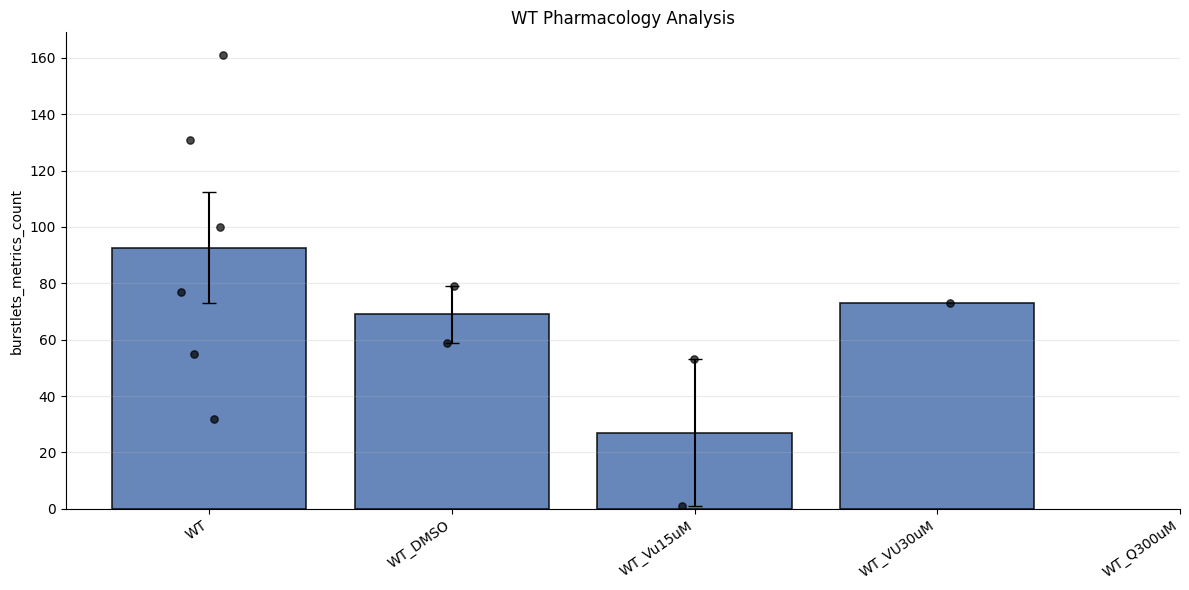


HET Pharmacology Analysis

            count        mean  median        std        sem
NeuronType                                                 
HET          11.0   98.363636    97.0  53.701532  16.191621
HET_DMSO      3.0  121.000000   123.0  27.055499  15.620499
HET_5uM       1.0   81.000000    81.0        NaN        NaN
HET_Q100uM    1.0    1.000000     1.0        NaN        NaN
HET_Vu15uM    1.0    2.000000     2.0        NaN        NaN
HET_VU30uM    1.0   19.000000    19.0        NaN        NaN
HET_Q300uM    NaN         NaN     NaN        NaN        NaN
Skipping HET_5uM (low N)
Skipping HET_Q100uM (low N)
Skipping HET_Vu15uM (low N)
Skipping HET_VU30uM (low N)
Skipping HET_Q300uM (low N)

-----------------------------
PAIRWISE COMPARISONS
-----------------------------

  baseline comparison  n_baseline  n_group  baseline_mean  group_mean     U  \
0      HET   HET_DMSO          11        3      98.363636       121.0  11.0   

   p_uncorrected     p_fdr  significant  
0       0.4

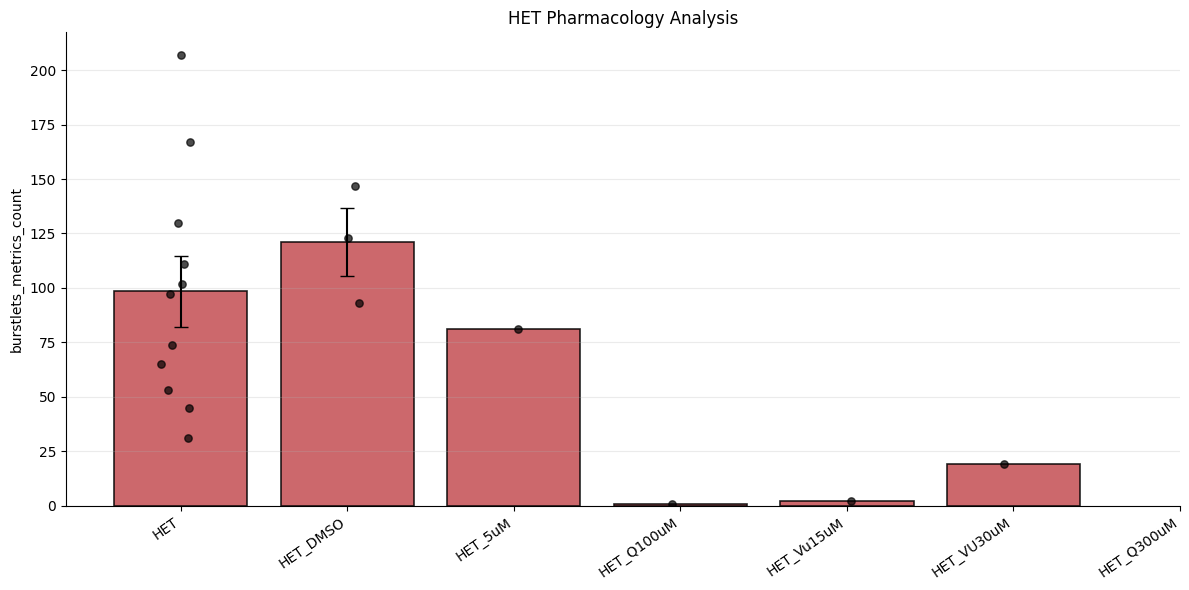

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# =========================================================
# SETTINGS
# =========================================================

metric_col = 'burstlets_metrics_count'

# ---------------------------------------------------------
# BASELINE RUNS (GREEN)
# ---------------------------------------------------------

baseline_runs = [
    108, 109, 111, 112, 114, 115,
    135, 136, 139, 140, 142, 145
]

# ---------------------------------------------------------
# DRUG RUNS (YELLOW)
# ---------------------------------------------------------

drug_runs = [
    119, 121, 123,
    146, 149, 151, 153, 156, 157
]

# =========================================================
# COPY DATA
# =========================================================

df = network_assay_df.copy()

# =========================================================
# CLEAN
# =========================================================

df[metric_col] = pd.to_numeric(
    df[metric_col],
    errors='coerce'
)

df = df.dropna(subset=[metric_col])

# =========================================================
# KEEP ONLY RELEVANT RUNS
# =========================================================

df = df[
    df['run_id'].isin(
        baseline_runs + drug_runs
    )
].copy()

# =========================================================
# DEFINE GROUPS
# =========================================================

wt_groups = [
    'WT',
    'WT_DMSO',
    'WT_Vu15uM',
    'WT_VU30uM',
    'WT_Q300uM'
]

het_groups = [
    'HET',
    'HET_DMSO',
    'HET_5uM',
    'HET_Q100uM',
    'HET_Vu15uM',
    'HET_VU30uM',
    'HET_Q300uM'
]

# =========================================================
# SUMMARY FUNCTION
# =========================================================

def summarize_groups(dataframe, groups):

    summary = (
        dataframe[
            dataframe['NeuronType'].isin(groups)
        ]
        .groupby('NeuronType', observed=True)[metric_col]
        .agg(['count', 'mean', 'median', 'std'])
        .reindex(groups)
    )

    summary['sem'] = (
        summary['std'] /
        np.sqrt(summary['count'])
    )

    return summary

# =========================================================
# PLOTTING FUNCTION
# =========================================================

def plot_family(groups, title, baseline_name):

    # -----------------------------------------------------
    # SUBSET
    # -----------------------------------------------------

    sub_df = df[
        df['NeuronType'].isin(groups)
    ].copy()

    # -----------------------------------------------------
    # SUMMARY
    # -----------------------------------------------------

    summary = summarize_groups(sub_df, groups)

    print('\n================================================')
    print(title)
    print('================================================\n')

    print(summary)

    # -----------------------------------------------------
    # PLANNED COMPARISONS
    # -----------------------------------------------------

    comparisons = []

    pvals = []

    for group in groups:

        if group == baseline_name:
            continue

        x = sub_df.loc[
            sub_df['NeuronType'] == baseline_name,
            metric_col
        ].to_numpy()

        y = sub_df.loc[
            sub_df['NeuronType'] == group,
            metric_col
        ].to_numpy()

        if len(x) < 2 or len(y) < 2:
            print(f'Skipping {group} (low N)')
            continue

        # ---------------------------------------------
        # NONPARAMETRIC TEST
        # ---------------------------------------------

        stat, p = mannwhitneyu(
            x,
            y,
            alternative='two-sided'
        )

        comparisons.append({
            'baseline': baseline_name,
            'comparison': group,
            'n_baseline': len(x),
            'n_group': len(y),
            'baseline_mean': np.mean(x),
            'group_mean': np.mean(y),
            'U': stat,
            'p_uncorrected': p
        })

        pvals.append(p)

    # -----------------------------------------------------
    # FDR CORRECTION
    # -----------------------------------------------------

    if len(comparisons) > 0:

        reject, p_fdr, _, _ = multipletests(
            pvals,
            method='fdr_bh'
        )

        for i in range(len(comparisons)):
            comparisons[i]['p_fdr'] = p_fdr[i]
            comparisons[i]['significant'] = reject[i]

        results_df = pd.DataFrame(comparisons)

        print('\n-----------------------------')
        print('PAIRWISE COMPARISONS')
        print('-----------------------------\n')

        print(results_df)

    # =====================================================
    # BAR PLOT
    # =====================================================

    fig, ax = plt.subplots(figsize=(12, 6))

    xpos = np.arange(len(groups))

    means = summary['mean'].to_numpy()
    sems = summary['sem'].to_numpy()

    # -----------------------------------------------------
    # COLORS
    # -----------------------------------------------------

    colors = []

    for g in groups:

        if g.startswith('WT'):
            colors.append('#4C72B0')

        else:
            colors.append('#C44E52')

    # -----------------------------------------------------
    # BARS
    # -----------------------------------------------------

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=5,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.85
    )

    # =====================================================
    # OVERLAY RAW DATA
    # =====================================================

    rng = np.random.default_rng(42)

    for i, g in enumerate(groups):

        y = sub_df.loc[
            sub_df['NeuronType'] == g,
            metric_col
        ].to_numpy()

        jitter = rng.normal(
            0,
            0.06,
            size=len(y)
        )

        ax.scatter(
            np.full(len(y), i) + jitter,
            y,
            color='black',
            alpha=0.7,
            s=28,
            zorder=3
        )

    # =====================================================
    # FORMATTING
    # =====================================================

    ax.set_xticks(xpos)

    ax.set_xticklabels(
        groups,
        rotation=35,
        ha='right'
    )

    ax.set_ylabel(metric_col)

    ax.set_title(title)

    ax.grid(axis='y', alpha=0.25)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# =========================================================
# WT ANALYSIS
# =========================================================

plot_family(
    groups=wt_groups,
    title='WT Pharmacology Analysis',
    baseline_name='WT'
)

# =========================================================
# HET ANALYSIS
# =========================================================

plot_family(
    groups=het_groups,
    title='HET Pharmacology Analysis',
    baseline_name='HET'
)

In [ ]:













import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import sem, ttest_ind, levene
from itertools import combinations

def analyze_organoid_pairwise_final(
    df,
    value_col,
    order=('Healthy', 'E198K', 'E200K'),
    palette={'Healthy': 'black', 'E198K': '#ff7f0e', 'E200K': 'cornflowerblue'},
    feature_label=None,
    save_path=None
):
    """
    Standardized HD-MEA Analysis for Organoids:
    - Auto-selects Student/Welch T-test per comparison.
    - Publication-quality brackets (no messy text on plots).
    - Robust error handling for NaN/Zero-variance data.
    """
    
    # 1. DATA PREP & CLEANING
    sub = df[['DIV', 'NeuronType', value_col]].copy().dropna(subset=[value_col])
    
    # Handle entirely empty columns
    if sub.empty:
        print(f"[SKIP] {value_col}: No data points found.")
        return

    divs = sorted(sub['DIV'].unique())

    # 2. SUMMARY TABLE (Mean, SEM, N)
    summary = sub.groupby(['DIV', 'NeuronType']).agg(
        mean=(value_col, 'mean'),
        sem=(value_col, lambda x: sem(x, nan_policy='omit')),
        n=(value_col, 'count')
    ).reindex(order, level='NeuronType').reset_index()

    # 3. PAIRWISE STATS WITH AUTO-SELECTION (Student vs Welch)
    stats_list = []
    pairs = list(combinations(order, 2))

    def get_stars(p):
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return None

    for div in divs:
        day_data = sub[sub['DIV'] == div]
        for g1, g2 in pairs:
            v1 = day_data[day_data['NeuronType'] == g1][value_col].values
            v2 = day_data[day_data['NeuronType'] == g2][value_col].values

            if len(v1) >= 2 and len(v2) >= 2:
                # Levene's test to check variance equality
                _, p_lev = levene(v1, v2)
                equal_var = p_lev > 0.05
                test_type = "Student" if equal_var else "Welch"

                # Run appropriate T-test
                _, p = ttest_ind(v1, v2, equal_var=equal_var, nan_policy='omit')
                
                stats_list.append({
                    'DIV': div, 'G1': g1, 'G2': g2, 'Comparison': f"{g1} vs {g2}",
                    'p_raw': p, 'test_used': test_type, 'sig': get_stars(p)
                })
            else:
                stats_list.append({
                    'DIV': div, 'G1': g1, 'G2': g2, 'Comparison': f"{g1} vs {g2}",
                    'p_raw': np.nan, 'test_used': 'N<2', 'sig': None
                })

    stats_df = pd.DataFrame(stats_list)

    # 4. PLOTTING WITH ROBUST LIMITS
    fig, ax = plt.subplots(figsize=(10, 6))
    DIV_SPACING, GENO_SPACING = 2.0, 0.3
    div_to_x = {d: i * DIV_SPACING for i, d in enumerate(divs)}
    offsets = {g: (i - (len(order)-1)/2) * GENO_SPACING for i, g in enumerate(order)}

    # --- CRITICAL: Robust Y-Limit Logic to prevent NaN/Inf Errors ---
    yvals = sub[value_col].dropna().values
    yvals = yvals[np.isfinite(yvals)]
    
    if len(yvals) == 0:
        print(f"[SKIP] {value_col}: No finite values to plot.")
        plt.close(fig)
        return

    y_l, y_h = np.nanpercentile(yvals, 1), np.nanpercentile(yvals, 99)
    yr = (y_h - y_l)
    
    # If data is flat, create a dummy range
    if yr == 0:
        yr = abs(y_h) * 0.1 if y_h != 0 else 1.0
        
    if not np.isfinite(y_l) or not np.isfinite(y_h):
        print(f"[SKIP] {value_col}: Calculation resulted in non-finite limits.")
        plt.close(fig)
        return

    ax.set_ylim(y_l - 0.15 * yr, y_h + 0.8 * yr)

    # 5. DRAW DATA
    for nt in order:
        d_nt = sub[sub['NeuronType'] == nt]
        s_nt = summary[summary['NeuronType'] == nt]
        
        # Jittered Raw Points
        x_raw = d_nt['DIV'].map(div_to_x) + offsets[nt] + (np.random.rand(len(d_nt))-0.5)*0.1
        ax.scatter(x_raw, d_nt[value_col], color=palette[nt], alpha=0.15, s=25, zorder=1)
        
        # Mean & SEM Line
        x_m = s_nt['DIV'].map(div_to_x) + offsets[nt]
        ax.plot(x_m, s_nt['mean'], '-o', color=palette[nt], label=nt, lw=2.5, zorder=3)
        ax.fill_between(x_m, s_nt['mean']-s_nt['sem'], s_nt['mean']+s_nt['sem'], 
                        color=palette[nt], alpha=0.1, zorder=2)

    # 6. DRAW SIGNIFICANCE BRACKETS
    for div in divs:
        div_sig = stats_df[(stats_df['DIV'] == div) & (stats_df['sig'].notna())]
        
        # Determine starting height for brackets at this DIV
        y_max_at_div = summary[summary['DIV'] == div].apply(lambda x: x['mean'] + x['sem'], axis=1).max()
        # Ensure brackets are at least above the local data points
        y_start = max(y_max_at_div + 0.05 * yr, y_l + 0.1 * yr)

        for i, (_, row) in enumerate(div_sig.iterrows()):
            x1 = div_to_x[div] + offsets[row['G1']]
            x2 = div_to_x[div] + offsets[row['G2']]
            
            # Increment Y height for multiple brackets
            y = y_start + (i * 0.15 * yr)
            h = 0.03 * yr # bracket tick height
            
            # Drawing
            ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.2, color='#444444')
            ax.text((x1+x2)/2, y + 0.01*yr, row['sig'], ha='center', va='bottom', 
                    fontsize=12, fontweight='bold', color='black')

    # 7. FINAL POLISH
    ax.set_xticks([div_to_x[d] for d in divs])
    ax.set_xticklabels(divs)
    ax.set_xlabel('Days In Vitro (DIV)', fontweight='bold')
    ax.set_ylabel(feature_label or value_col, fontweight='bold')
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
    ax.spines[['top', 'right']].set_visible(False)
    
    # 8. CONSOLE OUTPUT
    print(f"\n{'='*60}\nFEATURE: {value_col}\n{'='*60}")
    print("\n[SUMMARY TABLE]")
    print(summary[['DIV', 'NeuronType', 'n', 'mean', 'sem']].to_string(index=False))
    print("\n[STATISTICAL LOG: Student/Welch Selection]")
    print(stats_df[['DIV', 'Comparison', 'test_used', 'p_raw', 'sig']].dropna(subset=['p_raw']).to_string(index=False))

    plt.tight_layout()
    if save_path: 
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #plt.show()
    return fig


In [ ]:
cols_to_plot = [ 'nb_count',
       'nb_rate_hz', 'nb_duration_mean_s', 'nb_ibi_mean_s','nb_fragment_count_mean',
       'nb_spikes_per_burst_mean', 'nb_participation_mean',
     'sb_count', 'sb_rate_hz',
       'sb_duration_mean_s', 'sb_ibi_mean_s', 'sb_spikes_per_burst_mean',
       'sb_participation_mean', 'bl_count',
       'bl_rate_hz', 'bl_duration_mean_s', 'bl_ibi_mean_s',
       'bl_spikes_per_burst_mean', 'bl_participation_mean',
        'num_units'
       ]
for col in cols_to_plot:
    analyze_organoid_pairwise_final(
        neuronal_assay_df,
        value_col=col,
        feature_label=col.replace('_', ' ').title(),
        order=(  'CSB3 Healthy', 'CSB3 E198K','CSB3 E200K'),
        palette={ 'CSB3 Healthy': 'black','CSB3 E198K': '#ff7f0e', 'CSB3 E200K': 'cornflowerblue'},
        #save_path=f"/pscratch/sd/m/mpatil1/MEA_Analysis/IPNAnalysis/workbooks/plots/{col}_lineplot.svg"
    )

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

def export_all_to_pdf(df, cols, filename="MEA_Analysis_Report.pdf"):
    """
    Runs the pairwise analysis for all columns and saves them into a single PDF.
    """
    # Initialize the PDF document
    with PdfPages(filename) as pdf:
        for col in cols:
            print(f"Processing: {col}...")
            
            # 1. Generate the plot using our robust function
            # Note: We need to modify the function slightly to RETURN the fig
            fig = analyze_organoid_pairwise_final(
                df,
                value_col=col,
                feature_label=col.replace('_', ' ').title(),
                order=('Healthy', 'E198K', 'E200K'),
                palette={'Healthy': 'black', 'E198K': '#ff7f0e', 'E200K': 'cornflowerblue'}
            )
            
            # 2. If a figure was successfully created, save it to the PDF
            if fig is not None:
                pdf.savefig(fig)
                plt.close(fig) # Memory management: very important for 20+ plots
            
    print(f"\nSuccessfully exported all {len(cols)} features to {filename}")

# --- QUICK TWEAK TO YOUR FUNCTION ---
# Ensure your 'analyze_organoid_pairwise_final' ends with:
# return fig 
# instead of plt.show()

In [ ]:
neuronal_assay_df.columns

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, ttest_ind, levene
from itertools import combinations
from matplotlib.backends.backend_pdf import PdfPages

def analyze_organoid_pairwise_pdf_version(
    df, 
    value_col, 
    order=['Healthy','Healthy_PPP2RSD+', 'E198K','E198K_PPP2RSD+', 'E200K',
       'E200K_PPP2RSD+'],
    #order=['CSB3 Healthy', 'CSB3 E198K', 'CSB3 E200K'],
    #palette={'CSB3 Healthy': '#444444', 'CSB3 E198K': '#d98b5f', 'CSB3 E200K': '#8ca2ba'},
    palette= {'Healthy_PPP2RSD+': 'purple', 'Healthy': 'black', 'E198K_PPP2RSD+': 'purple', 'E198K': 'black',
       'E200K_PPP2RSD+': 'purple', 'E200K': 'black'},
    feature_label=None
):
    # 1. DATA PREP
    sub = df[df['NeuronType'].isin(order)].copy()
    sub = sub[['DIV', 'NeuronType', value_col]].dropna(subset=[value_col])
    
    if sub.empty:
        return None, None

    divs = sorted(sub['DIV'].unique())
    
    # 2. SUMMARY TABLE
    summary = sub.groupby(['DIV', 'NeuronType']).agg(
        mean=(value_col, 'mean'),
        sem=(value_col, lambda x: sem(x, nan_policy='omit')),
        n=(value_col, 'count')
    ).reindex(pd.MultiIndex.from_product([divs, order], names=['DIV', 'NeuronType'])).reset_index()

    # 3. PAIRWISE STATS
    stats_list = []
    pairs = list(combinations(order, 2))

    def get_stars(p):
        if p < 0.0001: return '****'
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return 'ns'

    for div in divs:
        day_data = sub[sub['DIV'] == div]
        for g1, g2 in pairs:
            v1 = day_data[day_data['NeuronType'] == g1][value_col].values
            v2 = day_data[day_data['NeuronType'] == g2][value_col].values
            if len(v1) >= 2 and len(v2) >= 2:
                _, p_lev = levene(v1, v2)
                equal_var = p_lev > 0.05
                test_type = "Student" if equal_var else "Welch"
                _, p = ttest_ind(v1, v2, equal_var=equal_var, nan_policy='omit')
                stats_list.append({'DIV': div, 'G1': g1, 'G2': g2, 'Comparison': f"{g1} vs {g2}",
                                   'p_raw': p, 'test_used': test_type, 'sig': get_stars(p)})
    stats_df = pd.DataFrame(stats_list)

    # 4. FIGURE: GROUPED BARS ACROSS DIVs
    fig_plot, ax = plt.subplots(figsize=(max(6, len(divs)*3), 6))
    
    n_groups = len(divs)
    n_bars = len(order)
    bar_width = 0.25
    group_spacing = 1.2  # Space between DIV clusters
    
    # Generate X positions
    indices = np.arange(n_groups) * group_spacing
    
    for i, nt in enumerate(order):
        # Filter summary for this genotype across all DIVs
        nt_summary = summary[summary['NeuronType'] == nt]
        x_offsets = indices + (i * bar_width)
        
        # Plot Bars
        ax.bar(x_offsets, nt_summary['mean'], width=bar_width, color=palette[nt], 
               alpha=0.6, edgecolor='black', linewidth=1, label=nt if i == 0 else "")
        
        # Plot Error Bars
        ax.errorbar(x_offsets, nt_summary['mean'], yerr=nt_summary['sem'], 
                    fmt='none', c='black', capsize=3, lw=1)
        
        # Plot Jittered Scatter for each DIV
        for j, div in enumerate(divs):
            points = sub[(sub['DIV'] == div) & (sub['NeuronType'] == nt)][value_col]
            jitter = (np.random.rand(len(points)) - 0.5) * (bar_width * 0.6)
            ax.scatter(np.full(len(points), x_offsets[j]) + jitter, points, 
                       color=palette[nt], edgecolor='black', alpha=0.4, s=20, zorder=3)

    # 5. STATISTICAL BRACKETS (Grouped per DIV)
    y_max_all = sub[value_col].max()
    yr = y_max_all * 0.1
    
    for j, div in enumerate(divs):
        div_x_start = indices[j]
        # Comparison 1: Healthy vs E198K
        comp1 = stats_df[(stats_df['DIV'] == div) & (stats_df['G1'] == order[0]) & (stats_df['G2'] == order[1])]
        if not comp1.empty and comp1['sig'].values[0] != 'ns':
            sig = comp1['sig'].values[0]
            x1, x2 = div_x_start, div_x_start + bar_width
            y = y_max_all + yr
            ax.plot([x1, x1, x2, x2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1)
            ax.text((x1+x2)/2, y, sig, ha='center', va='bottom', fontsize=9, fontweight='bold')
            
        # Comparison 2: Healthy vs E200K
        comp2 = stats_df[(stats_df['DIV'] == div) & (stats_df['G1'] == order[0]) & (stats_df['G2'] == order[2])]
        if not comp2.empty and comp2['sig'].values[0] != 'ns':
            sig = comp2['sig'].values[0]
            x1, x2 = div_x_start, div_x_start + (2 * bar_width)
            y = y_max_all + (yr * 2.5)
            ax.plot([x1, x1, x2, x2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1)
            ax.text((x1+x2)/2, y, sig, ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Formatting
    ax.set_xticks(indices + bar_width)
    ax.set_xticklabels([f"DIV {d}" for d in divs], fontweight='bold')
    ax.set_ylabel(feature_label or value_col, fontweight='bold')
    ax.set_title(feature_label, fontweight='bold', fontsize=14, pad=20)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Legend with cleaned names
    handles, labels = ax.get_legend_handles_labels()
    ax.legend([plt.Rectangle((0,0),1,1, color=palette[nt]) for nt in order], 
              [n.replace('CSB3 ', '') for n in order], frameon=False, loc='upper left', bbox_to_anchor=(1,1))

    plt.tight_layout()

    # 6. STATS TABLE PAGE
    fig_stats, ax_st = plt.subplots(figsize=(10, 8))
    ax_st.axis('off')
    if not stats_df.empty:
        display_stats = stats_df[['DIV', 'Comparison', 'p_raw', 'sig']].copy()
        display_stats['p_raw'] = display_stats['p_raw'].apply(lambda x: f"{x:.4e}" if pd.notnull(x) else "N/A")
        the_table = ax_st.table(cellText=display_stats.values, colLabels=display_stats.columns, loc='center', cellLoc='center')
        the_table.auto_set_font_size(False); the_table.set_fontsize(8); the_table.scale(1.2, 1.2)
    
    return fig_plot, fig_stats

def export_mea_analysis_to_pdf(df, cols,order,palette, output_name="MEA_Grouped_Report.pdf"):
    with PdfPages(output_name) as pdf:
        for col in cols:
            print(f"Plotting {col} across all DIVs...")
            label = col.replace('nb_', '').replace('_', ' ').title()
            fig_p, fig_s = analyze_organoid_pairwise_pdf_version(df, col, order=order, palette=palette, feature_label=label)
            if fig_p is not None:
                pdf.savefig(fig_p)
                pdf.savefig(fig_s)
                plt.close(fig_p)
                plt.close(fig_s)
    print(f"\nReport complete: {output_name}")

# --- EXECUTION ---
cols_to_plot = [
'num_units', 'bl_count', 'nb_count',
       'nb_rate_hz', 'nb_duration_mean_s', 'nb_ibi_mean_s',
       'nb_spikes_per_burst_mean', 'nb_participation_mean',
       'nb_burst_peak_mean','nb_peak_synchrony_mean',
       'nb_fragment_count_mean'
]

export_mea_analysis_to_pdf(neuronal_assay_df, cols_to_plot,  order=(  'CSB3 Healthy', 'CSB3 E198K','CSB3 E200K'),
        palette={ 'CSB3 Healthy': 'black','CSB3 E198K': '#ff7f0e', 'CSB3 E200K': 'cornflowerblue'},
                           output_name='/mnt/Vol20tb1/user_workspaces/shruti/MEA_Analysis/MEA_Analysis_V2/MEA_Analysis/AnalyzedData/JGA_CSB3_010825_VD/MEA_Graphs_Grouped.pdf')

In [ ]:
export_mea_analysis_to_pdf(neuronal_assay_df[neuronal_assay_df['DIV'] == 19], cols_to_plot,  order=(  'CSB3 Healthy', 'CSB3 E198K','CSB3 E200K'),
        palette={ 'CSB3 Healthy': 'black','CSB3 E198K': '#ff7f0e', 'CSB3 E200K': 'cornflowerblue'},
                           output_name='/mnt/Vol20tb1/user_workspaces/shruti/MEA_Analysis/MEA_Analysis_V2/MEA_Analysis/AnalyzedData/JGA_CSB3_010825_VD/MEA_Graphs_DIV19.pdf')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, ttest_ind
from itertools import combinations
from matplotlib.backends.backend_pdf import PdfPages

def analyze_organoid_pairwise_pdf_version(
    df, 
    value_col, 
    group_col='NeuronType',
    order=['Healthy','Healthy_PPP2RSD+', 'E198K','E198K_PPP2RSD+', 'E200K','E200K_PPP2RSD+'],
    palette= {'Healthy': 'black', 'Healthy_PPP2RSD+': 'purple', 
              'E198K': 'black', 'E198K_PPP2RSD+': 'purple', 
              'E200K': 'black', 'E200K_PPP2RSD+': 'purple'},
    feature_label=None
):
    # 1. DATA PREP
    sub = df[df[group_col].isin(order)].copy()
    sub = sub.dropna(subset=[value_col])
    if sub.empty: 
        print(f"No data for {value_col}")
        return None, None, None

    divs = sorted(sub['DIV'].unique())
    
    # Statistics Helpers
    def get_stars(p):
        if p < 0.0001: return '****'
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return 'ns'

    def run_welch_stats(data_subset, g_col, v_col, pairs):
        results = []
        for g1, g2 in pairs:
            v1 = data_subset[data_subset[g_col] == g1][v_col].values
            v2 = data_subset[data_subset[g_col] == g2][v_col].values
            if len(v1) >= 2 and len(v2) >= 2:
                _, p = ttest_ind(v1, v2, equal_var=False, nan_policy='omit')
                results.append({'G1': g1, 'G2': g2, 'Comparison': f"{g1} vs {g2}", 
                                'p_raw': p, 'test_used': "Welch's T", 'sig': get_stars(p)})
        return pd.DataFrame(results)

    # 2. RUN STATISTICS
    pairs = list(combinations(order, 2))
    div_stats_list = []
    for div in divs:
        d_stats = run_welch_stats(sub[sub['DIV'] == div], group_col, value_col, pairs)
        if not d_stats.empty:
            d_stats['DIV'] = div
            div_stats_list.append(d_stats)
    
    stats_df = pd.concat(div_stats_list) if div_stats_list else pd.DataFrame()
    agg_stats_df = run_welch_stats(sub, group_col, value_col, pairs)

    # 3. FIGURE 1: GROUPED BARS ACROSS DIVs
    summary = sub.groupby(['DIV', group_col])[value_col].agg(['mean', lambda x: sem(x, nan_policy='omit')])
    summary.columns = ['mean', 'sem']
    summary = summary.reset_index()

    fig_div, ax = plt.subplots(figsize=(max(12, len(divs)*4.5), 8))
    group_spacing = 3.0 
    bar_width = 0.32
    indices = np.arange(len(divs)) * group_spacing
    
    y_max_global = sub[value_col].max()
    yr = y_max_global * 0.12

    for i, nt in enumerate(order):
        nt_summary = summary[summary[group_col] == nt].set_index('DIV').reindex(divs).reset_index()
        x_off = indices + (i * bar_width)
        
        ax.bar(x_off, nt_summary['mean'], width=bar_width, color=palette.get(nt, 'gray'), 
               alpha=0.6, edgecolor='black', linewidth=1.2)
        ax.errorbar(x_off, nt_summary['mean'], yerr=nt_summary['sem'], fmt='none', c='black', capsize=3)
        
        # GENOTYPE SUB-LABELS
        if i % 2 == 0:
            geno_text = nt.replace('_PPP2RSD+', '')
            for j, idx in enumerate(indices):
                ax.text(idx + (i * bar_width) + bar_width/2, -y_max_global*0.06, 
                        geno_text, ha='center', va='top', fontsize=9, fontweight='bold')

        for j, div in enumerate(divs):
            pts = sub[(sub['DIV'] == div) & (sub[group_col] == nt)][value_col]
            jitter = (np.random.rand(len(pts)) - 0.5) * (bar_width * 0.5)
            ax.scatter(np.full(len(pts), x_off[j]) + jitter, pts, color=palette.get(nt, 'gray'), 
                       edgecolor='white', alpha=0.4, s=15, zorder=3)

    # Brackets
    for j, div in enumerate(divs):
        div_x = indices[j]
        d_stats = stats_df[stats_df['DIV'] == div] if not stats_df.empty else pd.DataFrame()
        if d_stats.empty: continue

        def draw_b(idx1, idx2, y_lvl):
            p_stats = d_stats[((d_stats['G1'] == order[idx1]) & (d_stats['G2'] == order[idx2]))]
            if not p_stats.empty and p_stats['sig'].values[0] != 'ns':
                sig = p_stats['sig'].values[0]
                x1, x2 = div_x + (idx1 * bar_width), div_x + (idx2 * bar_width)
                y = y_max_global + (y_lvl * yr)
                ax.plot([x1, x1, x2, x2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1)
                ax.text((x1+x2)/2, y, sig, ha='center', va='bottom', fontsize=8, fontweight='bold')

        draw_b(0, 1, 0.5); draw_b(2, 3, 0.5); draw_b(4, 5, 0.5)
        draw_b(0, 2, 1.8); draw_b(2, 4, 1.8); draw_b(0, 4, 3.8)
        draw_b(1, 3, 2.8); draw_b(3, 5, 2.8); draw_b(1, 5, 4.8)

    ax.set_xticks(indices + (bar_width * 2.5))
    ax.set_xticklabels([f"DIV {int(d)}" for d in divs], fontweight='bold', fontsize=12)
    # Correct way to add padding to tick labels
    ax.tick_params(axis='x', which='major', pad=35) 
    
    ax.set_ylabel(feature_label, fontweight='bold')
    ax.set_title(f"{feature_label} per DIV (Paired NT/AAV Comparison)", fontweight='bold', pad=35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, y_max_global + (yr * 7))
    
    legend_elements = [plt.Rectangle((0,0),1,1, color='black', alpha=0.6, label='NT (No Treatment)'),
                       plt.Rectangle((0,0),1,1, color='purple', alpha=0.6, label='AAV (PPP2RSD+)')]
    ax.legend(handles=legend_elements, frameon=False, loc='upper left', bbox_to_anchor=(1,1))

    # 4. FIGURE 2: AGGREGATED
    agg_summary = sub.groupby(group_col)[value_col].agg(['mean', lambda x: sem(x, nan_policy='omit')])
    agg_summary.columns = ['mean', 'sem']
    agg_summary = agg_summary.reindex(order).reset_index()

    fig_agg, ax_agg = plt.subplots(figsize=(7, 7))
    for i, nt in enumerate(order):
        row = agg_summary.iloc[i]
        pts = sub[sub[group_col] == nt][value_col]
        ax_agg.bar(i, row['mean'], width=0.7, color=palette.get(nt, 'gray'), alpha=0.6, edgecolor='black')
        ax_agg.errorbar(i, row['mean'], yerr=row['sem'], fmt='none', c='black', capsize=5)
        ax_agg.scatter(np.full(len(pts), i) + (np.random.rand(len(pts))-0.5)*0.4, pts, 
                       color=palette.get(nt, 'gray'), edgecolor='white', alpha=0.4, s=20, zorder=3)

    for idx1, idx2, y_lvl in [(0,1,0.5), (2,3,0.5), (4,5,0.5), (0,2,1.8), (2,4,1.8), (0,4,3.8)]:
        sig_row = agg_stats_df[(agg_stats_df['G1'] == order[idx1]) & (agg_stats_df['G2'] == order[idx2])]
        if not sig_row.empty and sig_row['sig'].values[0] != 'ns':
            y = y_max_global + (yr * y_lvl)
            ax_agg.plot([idx1, idx1, idx2, idx2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1)
            ax_agg.text((idx1+idx2)/2, y, sig_row['sig'].values[0], ha='center', va='bottom', fontweight='bold')

    ax_agg.set_xticks(range(len(order)))
    ax_agg.set_xticklabels([n.replace('_PPP2RSD+', '+') for n in order], rotation=45, fontweight='bold')
    ax_agg.set_ylabel(feature_label, fontweight='bold')
    ax_agg.set_title(f"{feature_label} (Aggregated)", fontweight='bold', pad=25)
    ax_agg.spines[['top', 'right']].set_visible(False)
    ax_agg.set_ylim(0, y_max_global + (yr * 7))

    # 5. FIGURE 3: STATS TABLE
    fig_tbl, ax_tbl = plt.subplots(figsize=(10, 10))
    ax_tbl.axis('off')
    if not stats_df.empty:
        agg_tbl = agg_stats_df.copy(); agg_tbl['DIV'] = 'AGGREGATED'
        full_stats = pd.concat([stats_df, agg_tbl])[['DIV', 'Comparison', 'p_raw', 'sig']]
        full_stats['p_raw'] = full_stats['p_raw'].apply(lambda x: f"{x:.4e}" if pd.notnull(x) else "N/A")
        table = ax_tbl.table(cellText=full_stats.values, colLabels=full_stats.columns, loc='center', cellLoc='center')
        table.auto_set_font_size(False); table.set_fontsize(7); table.scale(1.1, 1.1)
        #ax_tbl.set_title(f"Detailed Statistics Table: {feature_label}", fontweight='bold')

    plt.tight_layout()
    return fig_div, fig_agg, fig_tbl

def export_mea_analysis_to_pdf(df, cols, output_name="Report.pdf"):
    with PdfPages(output_name) as pdf:
        for col in cols:
            if col not in df.columns: continue
            print(f"Processing Analysis: {col}")
            label = col.replace('nb_', '').replace('_', ' ').title()
            f1, f2, f3 = analyze_organoid_pairwise_pdf_version(df, col, feature_label=label)
            if f1 is not None:
                pdf.savefig(f1); pdf.savefig(f2); pdf.savefig(f3)
                plt.close(f1); plt.close(f2); plt.close(f3)
    print(f"\nCompleted! PDF saved: {output_name}")

# --- EXECUTION ---
cols_to_plot = ['nb_count', 'nb_rate_hz', 'nb_duration_mean_s', 'nb_spikes_per_burst_mean', 'num_units', 'bl_count', 'nb_burst_peak_mean']
export_mea_analysis_to_pdf(neuronal_assay_df, cols_to_plot, 
                           output_name='/mnt/Vol20tb1/user_workspaces/shruti/MEA_Analysis/MEA_Analysis_V2/MEA_Analysis/AnalyzedData/JGA_COB7_080825_VD/MEA_Graphs_Final_Paired_Labeled.pdf')

In [ ]:
neuronal_assay_df.head()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, ttest_ind
from itertools import combinations
from matplotlib.backends.backend_pdf import PdfPages

def analyze_organoid_pairwise_pdf_version(
    df, 
    value_col, 
    group_col='NeuronType',
    order=['CSB3 Healthy', 'CSB3 E198K', 'CSB3 E200K'],
    palette={'CSB3 Healthy': '#444444', 'CSB3 E198K': '#d98b5f', 'CSB3 E200K': '#8ca2ba'},
    feature_label=None
):
    # 1. DATA PREP
    # Filter for genotypes in order and drop NaNs
    sub = df[df[group_col].isin(order)].copy()
    sub = sub.dropna(subset=[value_col])
    
    if sub.empty:
        print(f"No data for {value_col}")
        return None, None, None

    divs = sorted(sub['DIV'].unique())
    
    # --- STATISTICS UTILITY (Strictly Welch's) ---
    def get_stars(p):
        if p < 0.0001: return '****'
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return 'ns'

    def run_welch_stats(data_subset, g_col, v_col, pairs):
        results = []
        for g1, g2 in pairs:
            v1 = data_subset[data_subset[g_col] == g1][v_col].values
            v2 = data_subset[data_subset[g_col] == g2][v_col].values
            if len(v1) >= 2 and len(v2) >= 2:
                # Independent t-test with Welch's correction
                _, p = ttest_ind(v1, v2, equal_var=False, nan_policy='omit')
                results.append({
                    'G1': g1, 'G2': g2, 'Comparison': f"{g1} vs {g2}", 
                    'p_raw': p, 'test_used': "Welch's T", 'sig': get_stars(p)
                })
        return pd.DataFrame(results)

    # 2. RUN STATISTICS
    pairs = list(combinations(order, 2))
    div_stats_list = []
    for div in divs:
        d_stats = run_welch_stats(sub[sub['DIV'] == div], group_col, value_col, pairs)
        if not d_stats.empty:
            d_stats['DIV'] = div
            div_stats_list.append(d_stats)
    
    stats_df = pd.concat(div_stats_list) if div_stats_list else pd.DataFrame()
    agg_stats_df = run_welch_stats(sub, group_col, value_col, pairs)

    # 3. FIGURE 1: GROUPED BARS ACROSS DIVs + SIGNIFICANCE
    summary = sub.groupby(['DIV', group_col])[value_col].agg(['mean', lambda x: sem(x, nan_policy='omit')])
    summary.columns = ['mean', 'sem']
    summary = summary.reset_index()

    fig_div, ax = plt.subplots(figsize=(max(8, len(divs)*3), 7))
    indices = np.arange(len(divs)) * 2.0 # Extra spacing for brackets
    bar_width = 0.4

    y_max_global = sub[value_col].max()
    yr = y_max_global * 0.12 # Vertical spacing unit for brackets

    for i, nt in enumerate(order):
        nt_summary = summary[summary[group_col] == nt].set_index('DIV').reindex(divs).reset_index()
        x_off = indices + (i * bar_width)
        
        # Plot Bars
        ax.bar(x_off, nt_summary['mean'], width=bar_width, color=palette.get(nt, 'gray'), 
               alpha=0.6, edgecolor='black', label=nt.replace('CSB3 ', ''))
        ax.errorbar(x_off, nt_summary['mean'], yerr=nt_summary['sem'], fmt='none', c='black', capsize=3)
        
        # Plot Jittered points
        for j, div in enumerate(divs):
            pts = sub[(sub['DIV'] == div) & (sub[group_col] == nt)][value_col]
            jitter = (np.random.rand(len(pts)) - 0.5) * (bar_width * 0.4)
            ax.scatter(np.full(len(pts), x_off[j]) + jitter, pts, color=palette.get(nt, 'gray'), 
                       edgecolor='black', alpha=0.3, s=15, zorder=3)

    # Draw Per-DIV significance bars
    for j, div in enumerate(divs):
        div_x_base = indices[j]
        day_stats = stats_df[stats_df['DIV'] == div] if not stats_df.empty else pd.DataFrame()
        if day_stats.empty: continue
        
        # Comparison 1: Healthy vs E198K
        s1 = day_stats[(day_stats['G1'] == order[0]) & (day_stats['G2'] == order[1])]
        if not s1.empty and s1['sig'].values[0] != 'ns':
            y = y_max_global + yr
            x1, x2 = div_x_base, div_x_base + bar_width
            ax.plot([x1, x1, x2, x2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1)
            ax.text((x1+x2)/2, y, s1['sig'].values[0], ha='center', va='bottom', fontsize=9, fontweight='bold')
            
        # Comparison 2: Healthy vs E200K
        s2 = day_stats[(day_stats['G1'] == order[0]) & (day_stats['G2'] == order[2])]
        if not s2.empty and s2['sig'].values[0] != 'ns':
            y = y_max_global + (yr * 2.5)
            x1, x2 = div_x_base, div_x_base + (2 * bar_width)
            ax.plot([x1, x1, x2, x2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1)
            ax.text((x1+x2)/2, y, s2['sig'].values[0], ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(indices + bar_width)
    ax.set_xticklabels([f"DIV {int(d)}" for d in divs], fontweight='bold')
    ax.set_ylabel(feature_label, fontweight='bold')
    ax.set_title(f"{feature_label} per DIV (Welch's T-test)", fontweight='bold', pad=25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, y_max_global + (yr * 6))
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))

    # 4. FIGURE 2: AGGREGATED PLOT
    agg_summary = sub.groupby(group_col)[value_col].agg(['mean', lambda x: sem(x, nan_policy='omit')])
    agg_summary.columns = ['mean', 'sem']
    agg_summary = agg_summary.reindex(order).reset_index()

    fig_agg, ax_agg = plt.subplots(figsize=(5, 6))
    for i, nt in enumerate(order):
        row = agg_summary.iloc[i]
        pts = sub[sub[group_col] == nt][value_col]
        ax_agg.bar(i, row['mean'], width=0.7, color=palette.get(nt, 'gray'), alpha=0.6, edgecolor='black')
        ax_agg.errorbar(i, row['mean'], yerr=row['sem'], fmt='none', c='black', capsize=5)
        ax_agg.scatter(np.full(len(pts), i) + (np.random.rand(len(pts))-0.5)*0.4, pts, 
                       color=palette.get(nt, 'gray'), edgecolor='black', alpha=0.3, s=20, zorder=3)

    # Brackets for Aggregated
    for i, (target_geno, y_lvl) in enumerate([(order[1], 1), (order[2], 2.5)]):
        sig_row = agg_stats_df[(agg_stats_df['G1'] == order[0]) & (agg_stats_df['G2'] == target_geno)]
        if not sig_row.empty and sig_row['sig'].values[0] != 'ns':
            y = y_max_global + (yr * y_lvl)
            x1, x2 = 0, order.index(target_geno)
            ax_agg.plot([x1, x1, x2, x2], [y-(yr*0.2), y, y, y-(yr*0.2)], color='black', lw=1.2)
            ax_agg.text((x1+x2)/2, y, sig_row['sig'].values[0], ha='center', va='bottom', fontweight='bold')

    ax_agg.set_xticks(range(len(order)))
    ax_agg.set_xticklabels([n.replace('CSB3 ', '') for n in order], fontweight='bold')
    ax_agg.set_ylabel(feature_label, fontweight='bold')
    ax_agg.set_title(f"{feature_label} (Aggregated)", fontweight='bold', pad=25)
    ax_agg.spines[['top', 'right']].set_visible(False)
    ax_agg.set_ylim(0, y_max_global + (yr * 6))

    # 5. FIGURE 3: STATS TABLE
    fig_tbl, ax_tbl = plt.subplots(figsize=(10, 8))
    ax_tbl.axis('off')
    if not stats_df.empty or not agg_stats_df.empty:
        agg_tbl = agg_stats_df.copy(); agg_tbl['DIV'] = 'AGGREGATED'
        full_stats = pd.concat([stats_df, agg_tbl])[['DIV', 'Comparison', 'test_used', 'p_raw', 'sig']]
        full_stats['p_raw'] = full_stats['p_raw'].apply(lambda x: f"{x:.4e}" if pd.notnull(x) else "N/A")
        
        table = ax_tbl.table(cellText=full_stats.values, colLabels=full_stats.columns, loc='center', cellLoc='center')
        table.auto_set_font_size(False); table.set_fontsize(8); table.scale(1.2, 1.2)
        ax_tbl.set_title(f"Statistical Summary Table: {feature_label}", fontweight='bold')

    plt.tight_layout()
    return fig_div, fig_agg, fig_tbl

def export_mea_analysis_to_pdf(df, cols, output_name="Report.pdf"):
    with PdfPages(output_name) as pdf:
        for col in cols:
            if col not in df.columns: continue
            print(f"Generating full analysis for: {col}")
            label = col.replace('nb_', '').replace('_', ' ').title()
            f1, f2, f3 = analyze_organoid_pairwise_pdf_version(df, col, feature_label=label)
            if f1 is not None:
                pdf.savefig(f1); pdf.savefig(f2); pdf.savefig(f3)
                plt.close(f1); plt.close(f2); plt.close(f3)
    print(f"\nPDF Report Saved: {output_name}")

# --- EXECUTION ---
# Using Welch's T-test for a robust biological comparison
export_mea_analysis_to_pdf(
    neuronal_assay_df, 
    ['nb_count', 'nb_rate_hz', 'nb_duration_mean_s', 'nb_spikes_per_burst_mean', 'num_units', 'bl_count', 'nb_burst_peak_mean', 'nb_peak_synchrony_mean'    ], 
    output_name='/mnt/Vol20tb1/user_workspaces/shruti/MEA_Analysis/MEA_Analysis_V2/MEA_Analysis/AnalyzedData/JGA_CSB3_010825_VD/MEA_Graphs_DIV19.pdf'
)

## Graphs ylim CUTOOF